# PROJET
## Advanced Marketing Analytics Business Intelligence & Decision Intelligence
##### Analyse de Données Avancée : Décisionnel & Business Intelligence

## PARTIE 1 : Data Audit & Data Quality

Réaliser un audit complet du dataset : typologie des variables, valeurs manquantes, doublons,
incohérences, outliers, anomalies de codage, variables potentiellement ambiguës et premiers risques
de biais.

• Identifier les problèmes de qualité pouvant affecter l’analyse.

• Proposer une stratégie de nettoyage et de transformation.

• Documenter les choix retenus et leur impact analytique.

##### IMPORT DE L'ENVRIRONNEMENT 

In [78]:
#importation des bibliothèques utiles 
import numpy as np
import scipy.stats as stats
import pandas as pd
import seaborn as sns #visualiser avec des syntaxes simples
import matplotlib.pyplot as plt #visualiserimport seaborn as sns

In [79]:
df=pd.read_csv("marketing_campaign.csv",sep=";")
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0


##### NETTOYAGE 

In [80]:
df.isna().sum()   #on regarde les valeurs manquantes

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [81]:
#on supprime les valeus manquantes étant seulement 24 
df=df.dropna()

In [82]:
#on verifie qu'il n'y a pas de duplicats
df.duplicated().sum()

0

In [83]:
# Age (via Year_Birth)
df["Age"] = 2024 - df["Year_Birth"]

df[df["Age"] > 100]

/var/folders/9s/qf8h3j8n015gknyh_038ykv40000gn/T/ipykernel_2899/2002177444.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Age"] = 2024 - df["Year_Birth"]


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
192,7829,1900,2n Cycle,Divorced,36640.0,1,0,2013-09-26,99,15,...,0,0,0,0,0,1,3,11,0,124
239,11004,1893,2n Cycle,Single,60182.0,0,1,2014-05-17,23,8,...,0,0,0,0,0,0,3,11,0,131
339,1150,1899,PhD,Together,83532.0,0,0,2013-09-26,36,755,...,0,0,1,0,0,0,3,11,0,125


In [84]:
df = df[df["Age"] < 100]

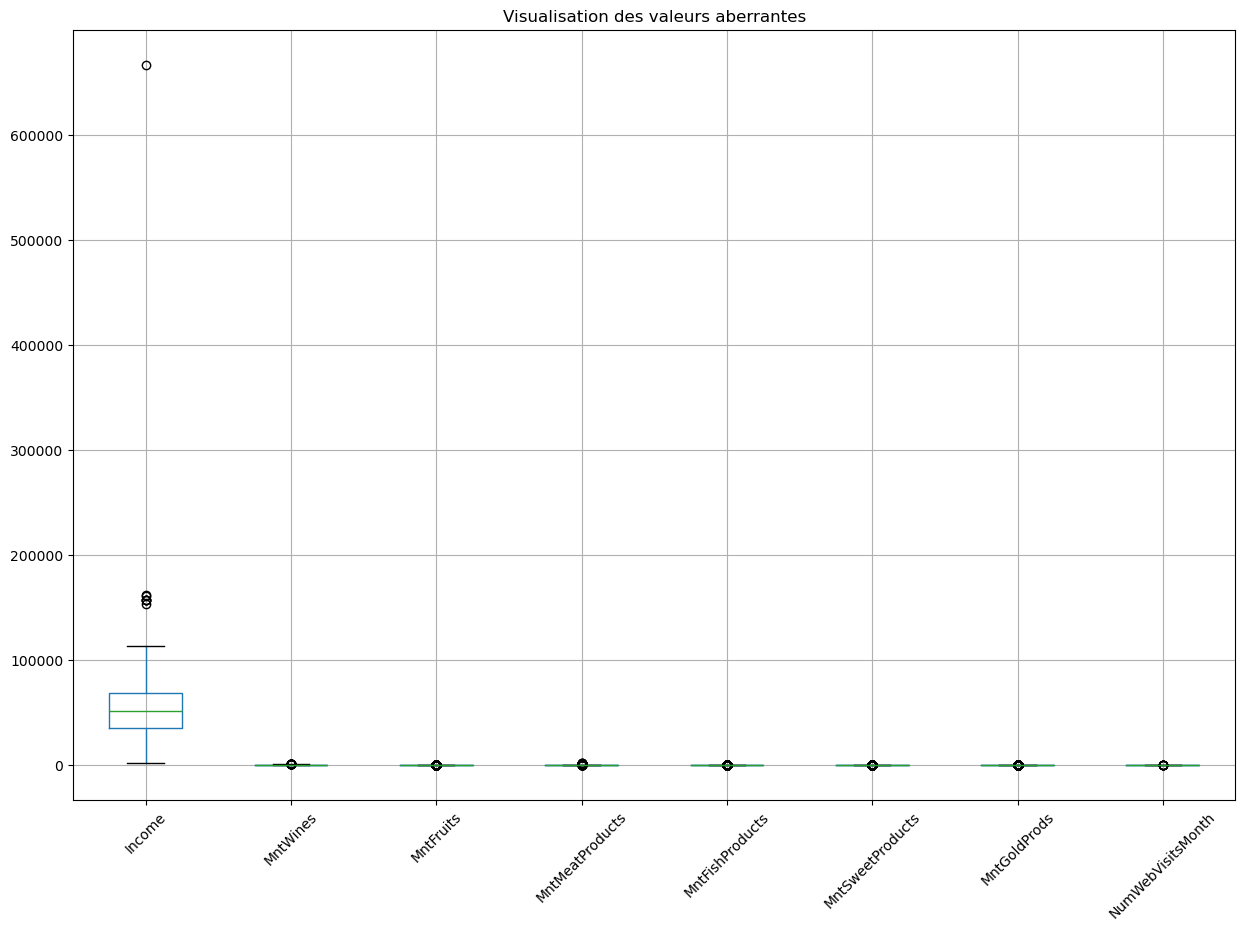

In [85]:
#il n'y a pas de valeurs dupliquées
#On vérifie les valeurs aberrantes 
# Sélection des colonnes numériques pour l'analyse
num_cols = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumWebVisitsMonth']

# Visualisation rapide avec des Boxplots
plt.figure(figsize=(15,10))
df[num_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Visualisation des valeurs aberrantes")
plt.show()

In [86]:
#on remarque une petite concentration de point vers le maximum, 
#et un point affirmant la présence de valeurs aberrantes. Pour plus de précision on calcul donc les quantiles 
# on utilise la methode de Tukeys

# Calcul des quartiles et de l'IQR
Q1= df['Income'].quantile(0.25)
Q3= df['Income'].quantile(0.75)
IQR= Q3 - Q1

#  On definit les seuils 
seuil_inf= Q1 - 1.5 * IQR
seuil_sup = Q3 + 1.5 * IQR

# On identifie les lignes aberrantes
val_hautes= df[df['Income'] > seuil_sup]
val_basses= df[df['Income'] < seuil_inf]

# On compte et affichage
nb_hautes= len(val_hautes)
nb_basses= len(val_basses)
total_aberrantes= nb_hautes + nb_basses
# Affichage des résultats

print(f"Seuil minimal (bas): {seuil_inf:,.2f} €")
print(f"Seuil maximal (haut): {seuil_sup:,.2f} €")
print(f"Nombre de lignes trop hautes: {nb_hautes}")
print(f"Nombre de lignes trop basses: {nb_basses}")
print(f"Total des lignes à traiter: {total_aberrantes}")
print(f"Pourcentage du dataset : {(total_aberrantes / len(df)) * 100:.2f}%")

Seuil minimal (bas): -14,615.50 €
Seuil maximal (haut): 118,348.50 €
Nombre de lignes trop hautes: 8
Nombre de lignes trop basses: 0
Total des lignes à traiter: 8
Pourcentage du dataset : 0.36%


In [87]:
#on remarque que les valeurs aberrantes ne représentent que 0.36%, on peut donc directement les supprimé.
df=df[df['Income'] <= seuil_sup]

Income                  Axes(0.125,0.653529;0.227941x0.226471)
MntWines             Axes(0.398529,0.653529;0.227941x0.226471)
MntFruits            Axes(0.672059,0.653529;0.227941x0.226471)
MntMeatProducts         Axes(0.125,0.381765;0.227941x0.226471)
MntFishProducts      Axes(0.398529,0.381765;0.227941x0.226471)
MntSweetProducts     Axes(0.672059,0.381765;0.227941x0.226471)
MntGoldProds                Axes(0.125,0.11;0.227941x0.226471)
NumWebVisitsMonth        Axes(0.398529,0.11;0.227941x0.226471)
dtype: object

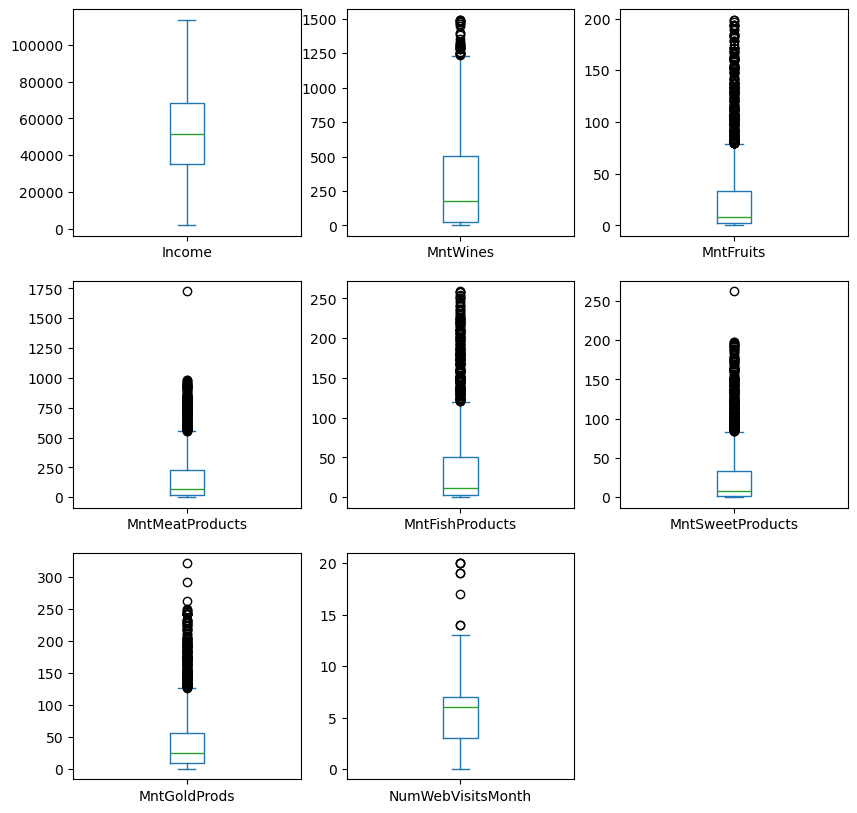

In [88]:
# On représente les boxplots des variables numériques à la bonne échelle
# On fait le même processus que pour la variable Income
df[num_cols].plot(kind="box", subplots=True,layout=(3,3), figsize=(10,10))

In [89]:
#on remarque qu'il y a des valeurs dépassant le seuil maximum, on applique donc la même méthode que pour la variable Income

In [90]:
# Liste des colonnes quantitatives à traiter
colonnes_quant = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 
    'MntSweetProducts', 'MntGoldProds', 'NumWebVisitsMonth', 'Recency'
]

for col in colonnes_quant:
    # 1. Calcul des seuils EIQ
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    EIQ = Q3 - Q1
    
    seuil_inferieur = Q1 - 1.5 * EIQ
    seuil_superieur = Q3 + 1.5 * EIQ
    
    # 2. Identification
    masque_aberrant = (df[col] < seuil_inferieur) | (df[col] > seuil_superieur)
    total_aberrantes = masque_aberrant.sum()
    pourcentage = (total_aberrantes / len(df)) * 100
    
    print(f" Analyse : {col}")
    print(f"Total aberrantes : {total_aberrantes} ({pourcentage:.2f}%)")
    
    # 3. Application de vos règles de décision
    if total_aberrantes == 0:
        print("Résultat : Aucune valeur aberrante détectée.")
        
    elif pourcentage < 5:
        # Action : Suppression
        df = df[~masque_aberrant]
        print(f"Action : < 5% détecté. Suppression des {total_aberrantes} lignes.")
        
    elif 5 <= pourcentage <= 20:
        # Action : Remplacement par la médiane
        mediane = df[col].median()
        df.loc[masque_aberrant, col] = mediane
        print(f"Action : Entre 5% et 20%. Remplacement par la médiane ({mediane}).")
        
    else:
        # Action : Alerte
        print(f"ALERTE : Trop de valeurs aberrantes ({pourcentage:.2f}%). Veuillez revoir le dataset pour cette variable.")

print("\n" + "="*30)
print(f"Traitement terminé. Taille finale du dataset : {df.shape[0]} lignes.")

 Analyse : MntWines
Total aberrantes : 34 (1.54%)
Action : < 5% détecté. Suppression des 34 lignes.
 Analyse : MntFruits
Total aberrantes : 241 (11.10%)
Action : Entre 5% et 20%. Remplacement par la médiane (8.0).
 Analyse : MntMeatProducts
Total aberrantes : 189 (8.71%)
Action : Entre 5% et 20%. Remplacement par la médiane (66.0).
 Analyse : MntFishProducts
Total aberrantes : 221 (10.18%)
Action : Entre 5% et 20%. Remplacement par la médiane (12.0).
 Analyse : MntSweetProducts
Total aberrantes : 252 (11.61%)
Action : Entre 5% et 20%. Remplacement par la médiane (8.0).
 Analyse : MntGoldProds
Total aberrantes : 198 (9.12%)
Action : Entre 5% et 20%. Remplacement par la médiane (24.0).
 Analyse : NumWebVisitsMonth
Total aberrantes : 9 (0.41%)
Action : < 5% détecté. Suppression des 9 lignes.
 Analyse : Recency
Total aberrantes : 0 (0.00%)
Résultat : Aucune valeur aberrante détectée.

Traitement terminé. Taille finale du dataset : 2162 lignes.


In [91]:
# On identifie et supprime les colonnes à valeur unique
#  colonnes avec une seule valeur
colonnes_constantes = [col for col in df.columns if df[col].nunique() <= 1]

# 2. Voir le contenu de ces colonnes avant de supprimer
for col in colonnes_constantes:
    valeur = df[col].unique()
    print(f"La colonne '{col}' est constante avec la valeur : {valeur}")

# 3. On Supprime
df.drop(columns=colonnes_constantes, inplace=True)
print(f"Colonnes supprimées : {len(colonnes_constantes)}")

La colonne 'Z_CostContact' est constante avec la valeur : [3]
La colonne 'Z_Revenue' est constante avec la valeur : [11]
Colonnes supprimées : 2


In [92]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,4,7,0,0,0,0,0,0,1,67
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,5,0,0,0,0,0,0,0,70
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,10,4,0,0,0,0,0,0,0,59
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,4,6,0,0,0,0,0,0,0,40
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,6,5,0,0,0,0,0,0,0,43


In [93]:
#Variables qualitatives
print(df['Marital_Status'].unique())

['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


In [94]:
#on remarque que single et alone ont la même signification, de plus absurd et yolo peuvent être mis dans une même catégorie
# Harmonisation des synonymes et suppression des valeurs absurdes
# On remplace 'Alone', 'Absurd' et 'YOLO' par 'Single' (ou 'Others' selon votre choix)
df['Marital_Status'] = df['Marital_Status'].replace({
    'Alone': 'Single',
    'Absurd': 'other',
    'YOLO': 'other'
})

# 2. Vérification du résultat
print("Nouvelles valeurs uniques :")
print(df['Marital_Status'].unique())


print(df['Marital_Status'].value_counts())

Nouvelles valeurs uniques :
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'other']
Marital_Status
Married     838
Together    557
Single      463
Divorced    226
Widow        74
other         4
Name: count, dtype: int64


In [95]:
df = df[df['Marital_Status'] != 'other']

In [96]:
#On fait de même pour éducation
print(df['Education'].unique())
print(df['Education'].value_counts())

['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
Education
Graduation    1097
PhD            452
Master         357
2n Cycle       198
Basic           54
Name: count, dtype: int64


In [97]:
#il n'y a pas de valeurs problématiques
#on vérifie l'âge
# Calcul des statistiques descriptives
stats = df['Year_Birth'].agg(['mean', 'median', 'max', 'min'])


print("Moyenne : ",{stats['mean']})
print("Médiane : ",{stats['median']})
print("Maximum : ",{stats['max']})
print("Minimum : ",{stats['min']})

Moyenne :  {1968.9624652455977}
Médiane :  {1970.0}
Maximum :  {1996.0}
Minimum :  {1940.0}


In [98]:
# Calcul des statistiques descriptives
stats = df['Year_Birth'].agg(['mean', 'median', 'max', 'min'])

print(f"Moyenne:{stats['mean']:.1f}")
print(f"Médiane:{stats['median']:.0f}")
print(f"Maximum:{stats['max']:.0f}")
print(f"Minimum:{stats['min']:.0f}")

Moyenne:1969.0
Médiane:1970
Maximum:1996
Minimum:1940


In [99]:
print(df['Dt_Customer'].dtype)
print(f"Valeurs nulles : {df['Dt_Customer'].isna().sum()}")

object
Valeurs nulles : 0


In [100]:
#  Conversion en datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%Y-%m-%d', errors='coerce')

# Vérification après conversion
print(df['Dt_Customer'].dtype)       
print(df['Dt_Customer'].head(5))   
print("Valeurs mal converties :", {df['Dt_Customer'].isna().sum()})

datetime64[ns]
0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[ns]
Valeurs mal converties : {0}


In [101]:
# On verifie enfin si les colonnes Kidhome et Teenhome ont des valeurs négatives
for col in ['Kidhome', 'Teenhome']:
    negatifs = df[df[col] < 0]
    print(f"{col} : {len(negatifs)} valeur(s) négative(s)")
    if len(negatifs) > 0:
        print(negatifs[[col]])

Kidhome : 0 valeur(s) négative(s)
Teenhome : 0 valeur(s) négative(s)


In [102]:
#il n'y a aucunes valeurs négatives, nous avons terminé le nettoyage de la base de donnée

## PARTIE 2 : Analyse multidimensionnelle et compréhension métier

Étudier la structure du portefeuille clients et dégager les premières logiques comportementales. Cette
analyse doit aller au-delà des statistiques descriptives classiques et mettre en évidence les dimensions
réellement utiles pour la décision.

• Comparer des profils selon le revenu, l’ancienneté, le niveau d’éducation, la composition du foyer et les comportements d’achat.

• Étudier les relations entre pouvoir d’achat, dépenses, fréquence d’achat et réponse marketing.

• Mettre en évidence les signaux marketing les plus discriminants.

---

##### CONSTRUCTION DE FEATURES VIA UNE ANALYSE 

Création de features pour simplifier les données

In [103]:
# Pour utiliser le champ Dt_Customer, nous allons créer une features qui calcule l'ancienneté des clients en année. 

from datetime import datetime
today = pd.to_datetime("today")
df['Customer_Years'] = (today - df['Dt_Customer']).dt.days / 365.25
df['Customer_Years'] = df['Customer_Years'].round(0)

In [104]:
df[['Dt_Customer', 'Customer_Years']].head()

,Dt_Customer,Customer_Years
0,2012-09-04,14.0
1,2014-03-08,12.0
2,2013-08-21,13.0
3,2014-02-10,12.0
4,2014-01-19,12.0


Les champs comme Kidhome/Teenhome ou MntWines/MntFruits/MntMeatProducts/MntFishProducts/MntSweetProducts/MntGoldProds ou NumDealsPurchases/NumWebPurchases/NumCatalogPurchases/NumStorePurchases ou 
'AcceptedCmp3'/'AcceptedCmp4'/'AcceptedCmp5'/'AcceptedCmp1'/'AcceptedCmp2' font parties des mêmes catégories, dont nous allons les analyser pour savoir s'il est possible de les regrouper en features 
et vérifier 3 choses : 

- les variables d’un même groupe racontent la même histoire

- aucune variable individuelle n’a un pouvoir prédictif fort qui serait dilué dans l’agrégation

- la variable composite améliore ou maintient la relation avec Response


In [105]:
# importer les librairies 

from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [106]:
# Étape 1 — Analyse bivariée vs Response

def analyse_bivariee(df, vars_group, target="Response"):
    X = df[vars_group]
    y = df[target]

    auc_scores = {}
    for col in vars_group:
        model = LogisticRegression(max_iter=300)
        model.fit(df[[col]], y)
        preds = model.predict_proba(df[[col]])[:, 1]
        auc_scores[col] = roc_auc_score(y, preds)

    mi_scores = mutual_info_classif(X, y, discrete_features=False)
    mi_scores = dict(zip(vars_group, mi_scores))

    print("\n=== AUC univariée ===")
    for k, v in auc_scores.items():
        print(f"{k}: {v:.3f}")

    print("\n=== Mutual Information ===")
    for k, v in mi_scores.items():
        print(f"{k}: {v:.3f}")

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df[vars_group])
    plt.title(f"Distribution des variables du groupe : {vars_group}")
    plt.show()


In [107]:
# Étape 2 : Analyse intra-groupe (corrélations + PCA)

def analyse_intragroupe(df, vars_group):
    corr = df[vars_group].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.title(f"Corrélations intra-groupe : {vars_group}")
    plt.show()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[vars_group])

    pca = PCA(n_components=2)
    pca.fit(X_scaled)

    print("Variance expliquée par PC1 et PC2 :", pca.explained_variance_ratio_)

In [108]:
# Étape 3 : pour aller encore plus loin dans la fiabilité de l'analyse - Comparaison de modèles (séparées vs composite)

def compare_modeles(df, vars_group, composite_name, target="Response"):
    df[composite_name] = df[vars_group].sum(axis=1)

    X_train_A, X_test_A, y_train, y_test = train_test_split(
        df[vars_group], df[target], test_size=0.3, random_state=42
    )

    X_train_B, X_test_B, _, _ = train_test_split(
        df[[composite_name]], df[target], test_size=0.3, random_state=42
    )

    X_train_C, X_test_C, _, _ = train_test_split(
        df[vars_group + [composite_name]], df[target], test_size=0.3, random_state=42
    )

    model_A = LogisticRegression(max_iter=300)
    model_A.fit(X_train_A, y_train)
    auc_A = roc_auc_score(y_test, model_A.predict_proba(X_test_A)[:, 1])

    model_B = LogisticRegression(max_iter=300)
    model_B.fit(X_train_B, y_train)
    auc_B = roc_auc_score(y_test, model_B.predict_proba(X_test_B)[:, 1])

    model_C = LogisticRegression(max_iter=300)
    model_C.fit(X_train_C, y_train)
    auc_C = roc_auc_score(y_test, model_C.predict_proba(X_test_C)[:, 1])

    print("\n=== Comparaison des modèles ===")
    print("AUC Modèle A (séparées) :", auc_A)
    print("AUC Modèle B (composite) :", auc_B)
    print("AUC Modèle C (mix)       :", auc_C)



=== AUC univariée ===
Kidhome: 0.544
Teenhome: 0.612

=== Mutual Information ===
Kidhome: 0.004
Teenhome: 0.009


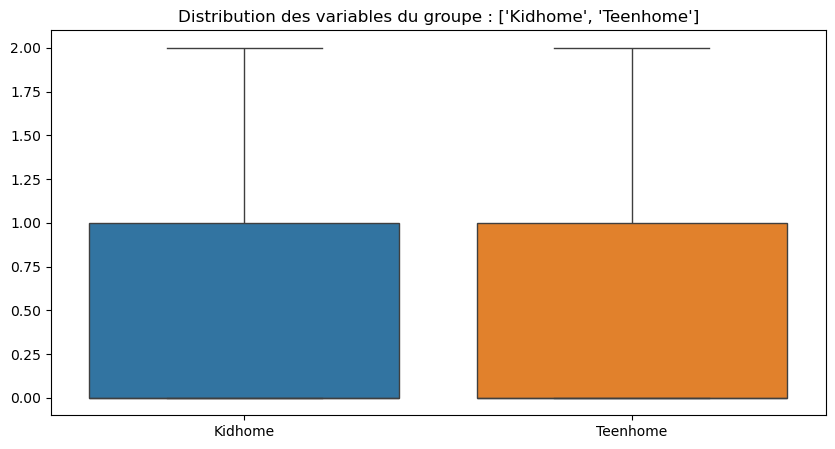

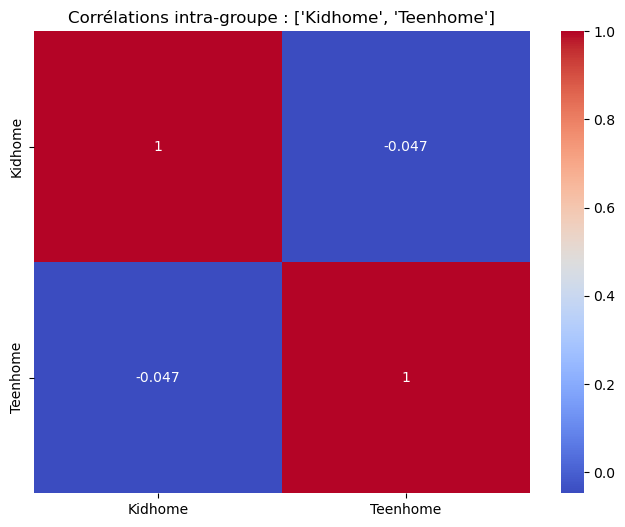

Variance expliquée par PC1 et PC2 : [0.52374004 0.47625996]

=== Comparaison des modèles ===
AUC Modèle A (séparées) : 0.6621550324675325
AUC Modèle B (composite) : 0.6370840097402597
AUC Modèle C (mix)       : 0.6621550324675325


In [109]:
# On appelle le groupe des "Enfants" 

vars_children = ["Kidhome", "Teenhome"]

analyse_bivariee(df, vars_children)
analyse_intragroupe(df, vars_children)
compare_modeles(df, vars_children, composite_name="Total_Children")


=== AUC univariée ===
MntWines: 0.641
MntFruits: 0.605
MntMeatProducts: 0.601
MntFishProducts: 0.568
MntSweetProducts: 0.589
MntGoldProds: 0.631

=== Mutual Information ===
MntWines: 0.028
MntFruits: 0.009
MntMeatProducts: 0.040
MntFishProducts: 0.003
MntSweetProducts: 0.011
MntGoldProds: 0.025


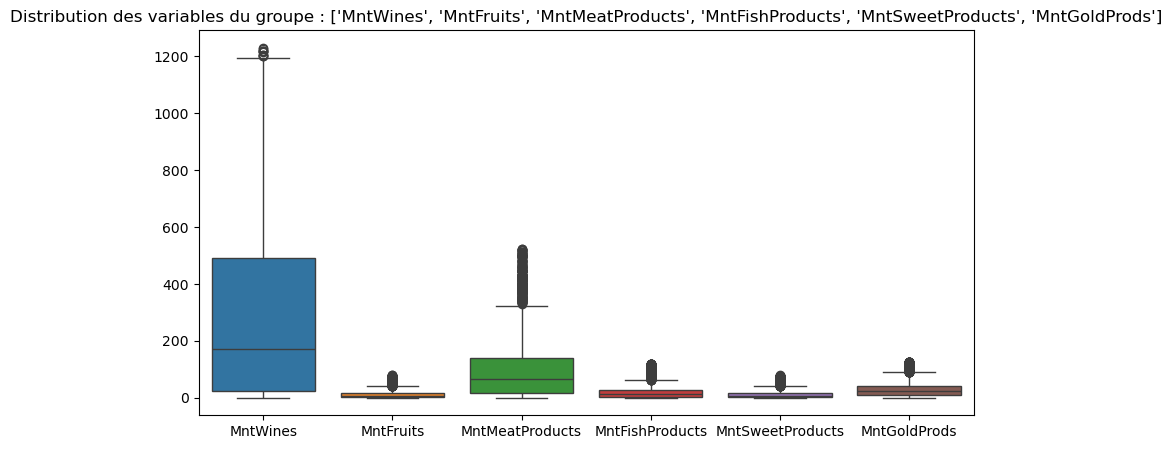

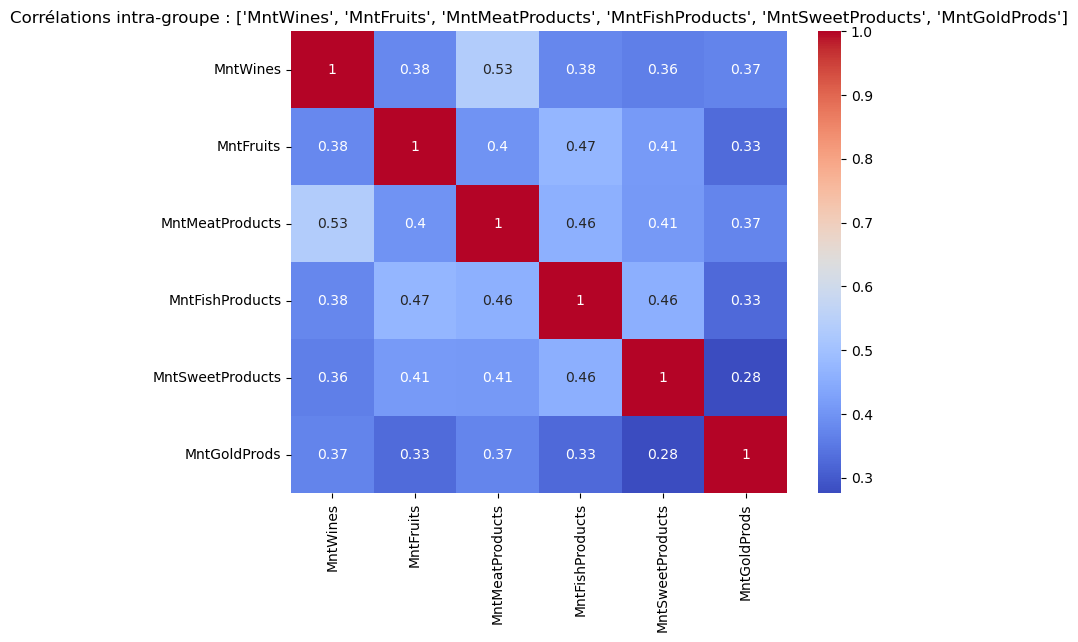

Variance expliquée par PC1 et PC2 : [0.49781851 0.13085152]

=== Comparaison des modèles ===
AUC Modèle A (séparées) : 0.6395799512987013
AUC Modèle B (composite) : 0.6578835227272728
AUC Modèle C (mix)       : 0.6395799512987013


In [110]:
# On appelle le groupe des "Dépenses" 

vars_spending = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]

analyse_bivariee(df, vars_spending)
analyse_intragroupe(df, vars_spending)
compare_modeles(df, vars_spending, composite_name="Total_Spending")


=== AUC univariée ===
NumDealsPurchases: 0.483
NumWebPurchases: 0.631
NumCatalogPurchases: 0.677
NumStorePurchases: 0.527

=== Mutual Information ===
NumDealsPurchases: 0.001
NumWebPurchases: 0.021
NumCatalogPurchases: 0.033
NumStorePurchases: 0.013


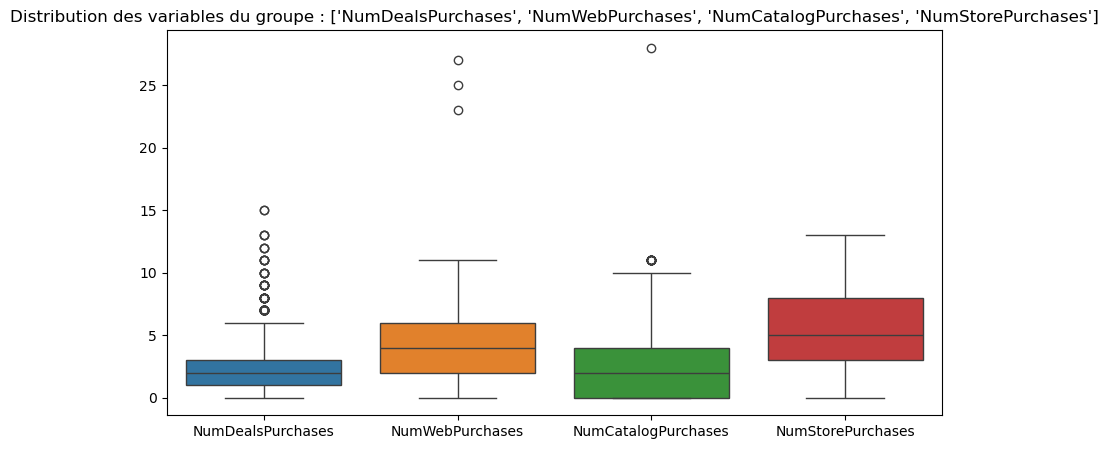

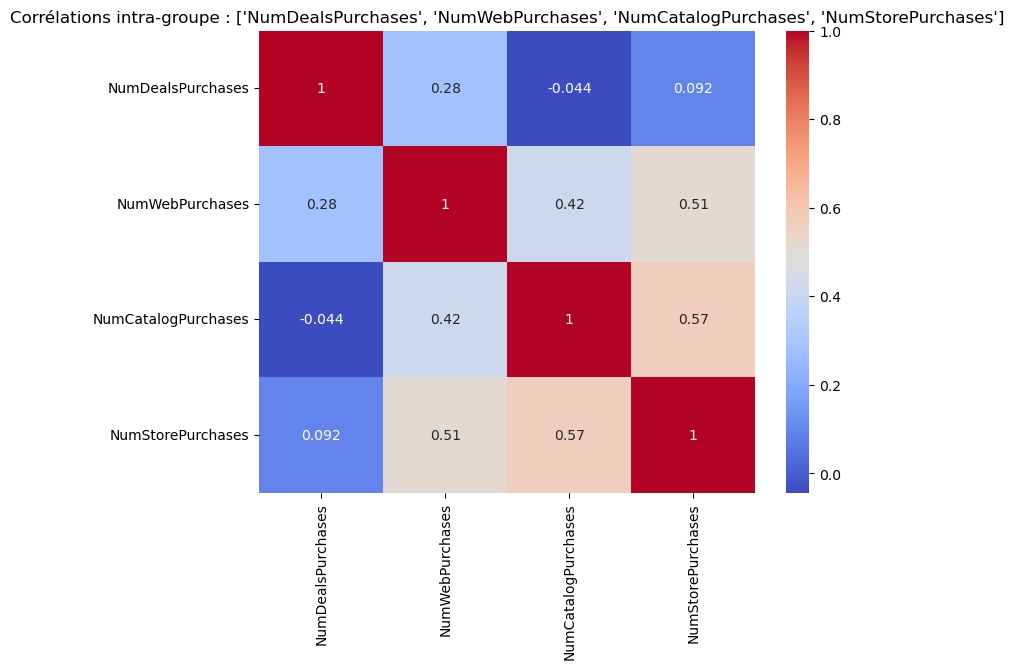

Variance expliquée par PC1 et PC2 : [0.50772487 0.26892213]

=== Comparaison des modèles ===
AUC Modèle A (séparées) : 0.7387987012987013
AUC Modèle B (composite) : 0.6205560064935065
AUC Modèle C (mix)       : 0.7389001623376624


In [111]:
# On appelle le groupe des "Achats" 

vars_purchases = [
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases"
]

analyse_bivariee(df, vars_purchases)
analyse_intragroupe(df, vars_purchases)
compare_modeles(df, vars_purchases, composite_name="Total_Purchases")


=== AUC univariée ===
AcceptedCmp1: 0.594
AcceptedCmp2: 0.519
AcceptedCmp3: 0.594
AcceptedCmp4: 0.554
AcceptedCmp5: 0.598

=== Mutual Information ===
AcceptedCmp1: 0.025
AcceptedCmp2: 0.003
AcceptedCmp3: 0.026
AcceptedCmp4: 0.005
AcceptedCmp5: 0.027


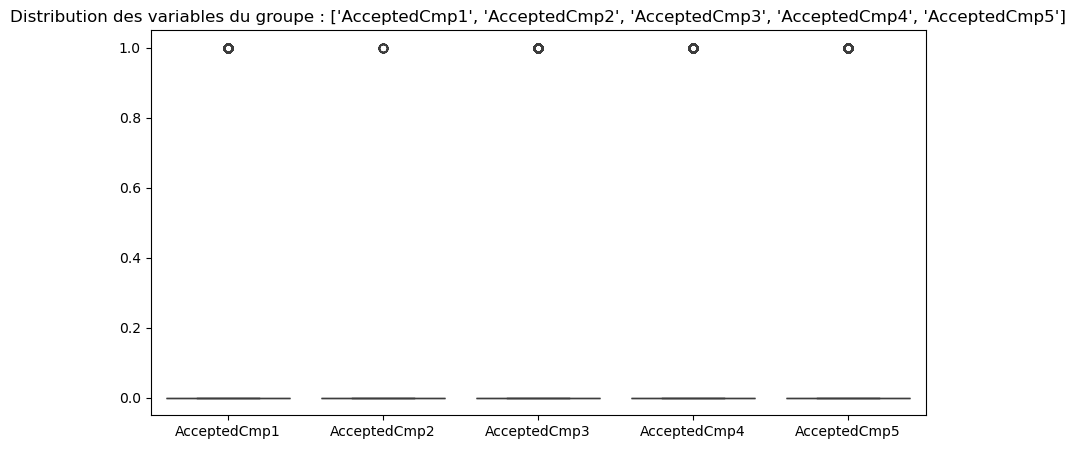

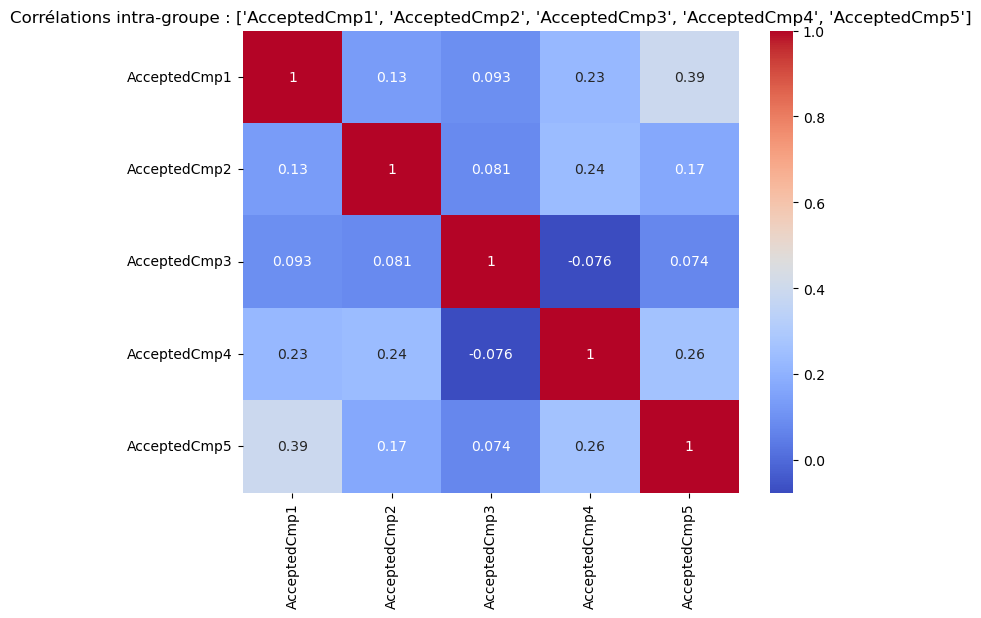

Variance expliquée par PC1 et PC2 : [0.3467565  0.21094697]

=== Comparaison des modèles ===
AUC Modèle A (séparées) : 0.6786931818181818
AUC Modèle B (composite) : 0.6770292207792208
AUC Modèle C (mix)       : 0.6787540584415584


In [112]:
# On appelle le groupe des "Réponses aux campagnes" 

vars_campaigns = [
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
    "AcceptedCmp4", "AcceptedCmp5"
]

analyse_bivariee(df, vars_campaigns)
analyse_intragroupe(df, vars_campaigns)
compare_modeles(df, vars_campaigns, composite_name="Total_Accepted_Campaigns")

CONCLUSION : 

- ENFANTS - PAS DE REGROUPEMENT : 

    Teenhome est plus informatif que Kidhome (AUC 0.612 vs 0.544).
    Mutual Information très faible → variables peu informatives individuellement.
    CA : PC1 = 52 %, PC2 = 48 % → les deux dimensions comptent, elles ne racontent pas la même histoire.
    Modèles : Séparées : 0.662 / Composite seule : 0.637 → perte d’info / Mix : 0.662 → identique au modèle séparé

- DÉPENSES - REGROUPEMENT & suppression des 6 variables individuelles sans perte d’information.

    Variables individuelles : AUC entre 0.56 et 0.64 → toutes informatives.
    Mutual Information faible mais cohérente.
    PCA : PC1 = 49 %, PC2 = 13 % → structure dominée par PC1, donc regroupement logique.
    Modèles : Séparées : 0.639 / Composite seule : 0.658 → meilleure performance / Mix : 0.639 → composite n’ajoute rien aux variables séparées

- ACHATS - PAS DE REGROUPEMENT & suppression de NumDealsPurchases (AUC < 0.5)

    AUC très variable : Catalog : 0.677 (très bon) / Web : 0.631 / Store : 0.527 / Deals : 0.483 (inutile)
    Mutual Information cohérente avec les AUC.
    PCA : PC1 = 50 %, PC2 = 27 % → pas de structure simple, variables hétérogènes.
    Modèles : Séparées : 0.739 / Composite seule : 0.621 → grosse perte d’information / Mix : 0.739 → composite n’apporte rien

- CAMPAGNES - REGROUPEMENT & suppression des variables pour simplifier

    AUC entre 0.52 et 0.60 → variables faibles mais cohérentes.
    Mutual Information faible.
    PCA : PC1 = 34 %, PC2 = 21 % → pas de structure forte, variables hétérogènes.
    Modèles : Séparées : 0.679 / Composite seule : 0.677 → quasi identique / Mix : 0.679 → composite n’ajoute rien mais simplifie le dataset 

In [113]:
# création de features pour regrouper les données 

# Dépenses totales
df["Total_Spending"] = df[
    ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
].sum(axis=1)

# Nb offres acceptées
cols = ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5"]
df["Total_Accepted_Campaigns"] = df[cols].sum(axis=1)

In [114]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Customer_Years',
       'Total_Children', 'Total_Spending', 'Total_Purchases',
       'Total_Accepted_Campaigns'],
      dtype='object')

On passe maintenant à la variable Income, qui serait plus lisible si on la regoupe dans 3 catégories : Low, Medium et High. Mais encore une fois, on vérifie bien la pertinence de cette feature. 

AUC Income continu : 0.6144604007193379
Mutual Information Income : 0.02948773533402771


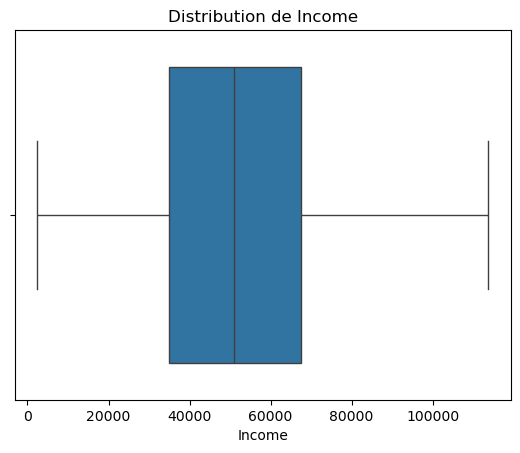

In [115]:
# Étape 1 : Analyse univariée

X = df[["Income"]]
y = df["Response"]

model = LogisticRegression(max_iter=300)
model.fit(X, y)
preds = model.predict_proba(X)[:, 1]

print("AUC Income continu :", roc_auc_score(y, preds))

mi = mutual_info_classif(X, y)
print("Mutual Information Income :", mi[0])

sns.boxplot(x=df["Income"])
plt.title("Distribution de Income")
plt.show()

In [116]:
# Étape 2 : Tester plusieurs découpages

# Equal Frequency (quantiles)
df["Income_q3"] = pd.qcut(df["Income"], q=3, labels=["Low", "Medium", "High"])

# Equal Width
df["Income_w3"] = pd.cut(df["Income"], bins=3, labels=["Low", "Medium", "High"])

# Custom business bins
df["Income_custom"] = pd.cut(
    df["Income"],
    bins=[0, 30000, 60000, df["Income"].max()],
    labels=["Low", "Medium", "High"])

In [117]:
# Étape 3 — Comparer les performances

def test_binning(colname):
    ct = ColumnTransformer(
        transformers=[("ohe", OneHotEncoder(drop="first"), [colname])],
        remainder="drop"
    )

    pipe = Pipeline([
        ("prep", ct),
        ("model", LogisticRegression(max_iter=300))
    ])

    pipe.fit(df[[colname]], y)
    preds = pipe.predict_proba(df[[colname]])[:, 1]
    auc = roc_auc_score(y, preds)
    print(f"AUC {colname} :", auc)

test_binning("Income_q3")
test_binning("Income_w3")
test_binning("Income_custom")

AUC Income_q3 : 0.6000684171951736
AUC Income_w3 : 0.6037782656153978
AUC Income_custom : 0.5862761721884973


CONCLUSION : 

- AUC = 0.614  / Mutual Information = 0.0287 : Income est modérément prédictif, mais il apporte une vraie information.
- Toutes les versions binned sont moins bonnes que la version continue. La perte est nette : de 0.614 → 0.586 / 0.600.
- Income est plus informatif en continu qu’en catégories.

In [118]:
# suppression des variables devenues inutiles

df = df.drop(["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds", "NumDealsPurchases", "Total_Purchases", "Total_Children", "Income_q3", "Income_w3", "Income_custom", "AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5"], axis=1)

---

##### ANALYSE UNIVARIÉE 

In [119]:
df.columns # on fait un point sur nos variables 

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Years', 'Total_Spending',
       'Total_Accepted_Campaigns'],
      dtype='object')

In [120]:
df.shape

(2158, 19)

On regarde la distribution des variables qualitatives : Education & Marital-Status.

Education
Graduation    1097
PhD            452
Master         357
2n Cycle       198
Basic           54
Name: count, dtype: int64


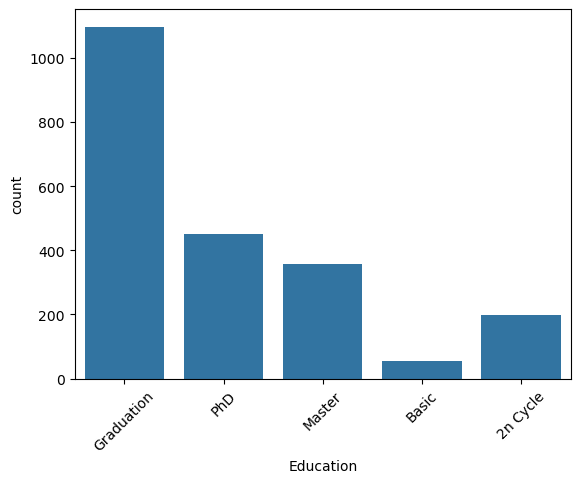

Marital_Status
Married     838
Together    557
Single      463
Divorced    226
Widow        74
Name: count, dtype: int64


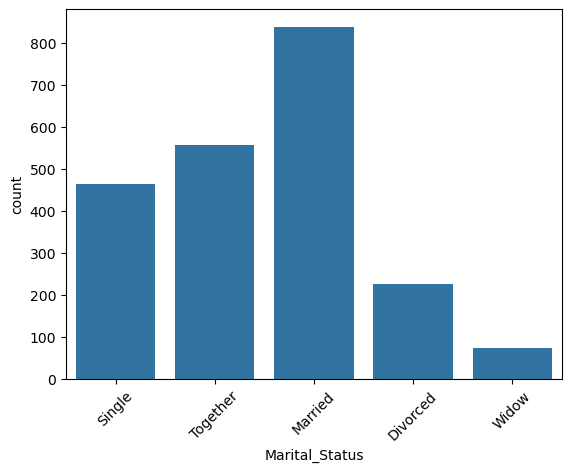

In [121]:
cat_cols = df[['Education', 'Marital_Status']].columns

for col in cat_cols:
    print(df[col].value_counts())
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.show()


OBSERVATION : 
- Graduation est la catégorie d'éducation dominante. 
- Married est la catégorie maritale la plus représentée dans ce dataset.

Maintenant, on va observer la répartition de la variable cible "Response" - 1 if customer accepted the offer in the last campaign, 0 otherwise - visualisation de la répartition des réponses à la campagne 

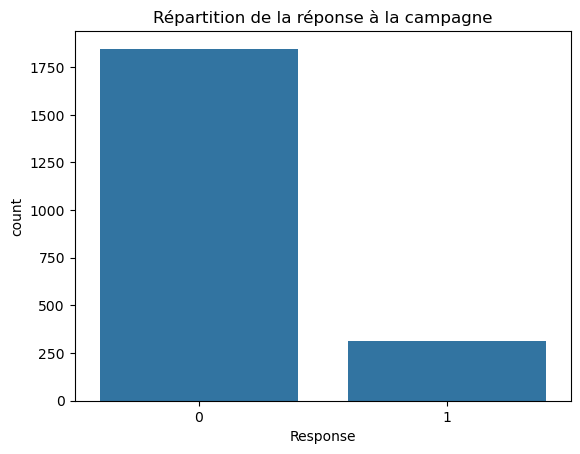

In [122]:
sns.countplot(data=df, x="Response")
plt.title("Répartition de la réponse à la campagne")
plt.show()

OBSERVATION : Déséquilibre avec une omniprésence de réponses négatives.

In [123]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Years', 'Total_Spending',
       'Total_Accepted_Campaigns'],
      dtype='object')

On regarde maintenant la distribution des variables que nous n'avons pas encore observées : 
'Income', 'Kidhome', 'Teenhome','Recency', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain','Age', 'Total_Spending', 'Total_Accepted_Campaigns'. 

Kidhome
0    1234
1     878
2      46
Name: count, dtype: int64


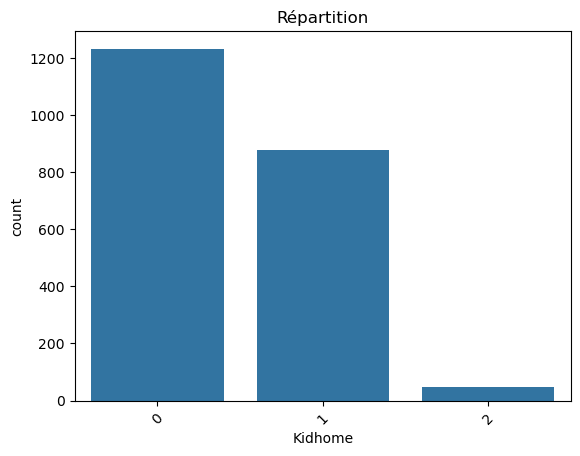

Teenhome
0    1108
1    1001
2      49
Name: count, dtype: int64


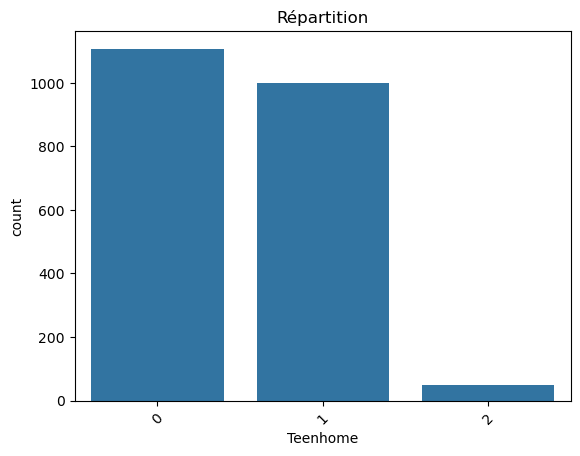

Complain
0    2138
1      20
Name: count, dtype: int64


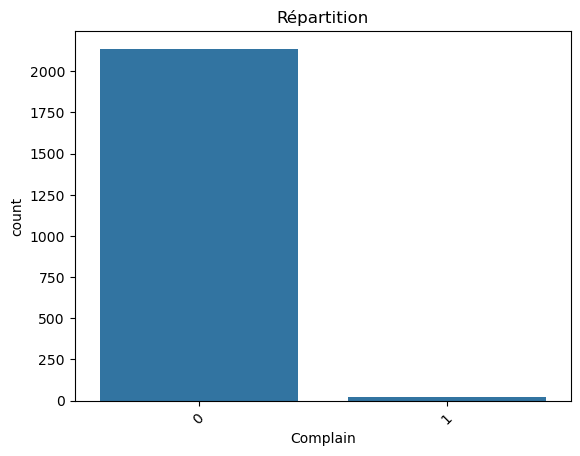

Total_Accepted_Campaigns
0    1730
1     315
2      69
3      38
4       6
Name: count, dtype: int64


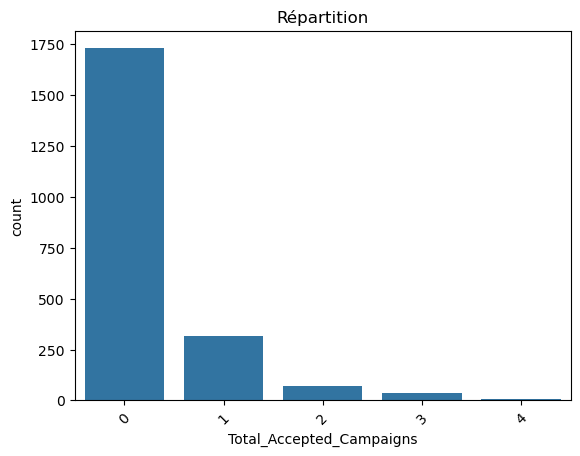

Customer_Years
13.0    1128
12.0     766
14.0     264
Name: count, dtype: int64


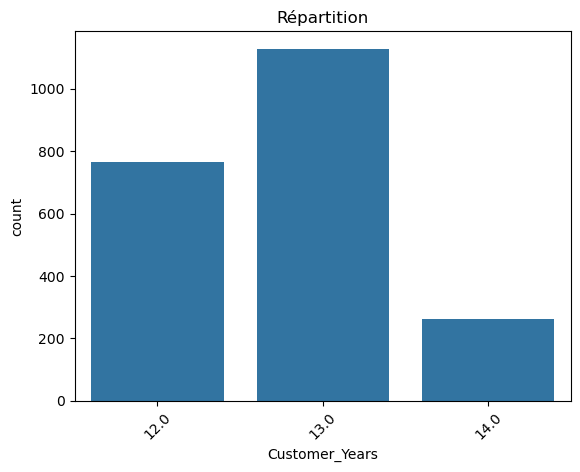

In [124]:
num_cols = df[['Kidhome', 'Teenhome', 'Complain', 'Total_Accepted_Campaigns', 'Customer_Years']].columns

for col in num_cols:
    print(df[col].value_counts())
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title("Répartition")
    plt.show()

OBSERVATION : 
- La majorité de la population observée à entre 0-1 kid et entre 0-1 teen 
- La majorité de la population observée n'a pas émis de plainte les 2 dernières années. 
- La majorité de la population observée n'a accepté aucune campagne, environ 1/5 a accepté une fois une campagne, et enfin très rares sont ceux qui ont accepté au moins 2 campagnes. 
- Il y a principalement 3 grands nombres d'ancienneté : 12, 13 et 14 ans. La majorité de la population observée se retrouve dans le 13 ans d'ancienneté. 

Enfin, nous allons observer la tendance des variables dont les dimensions sont plus importantes, sous une autre forme : 

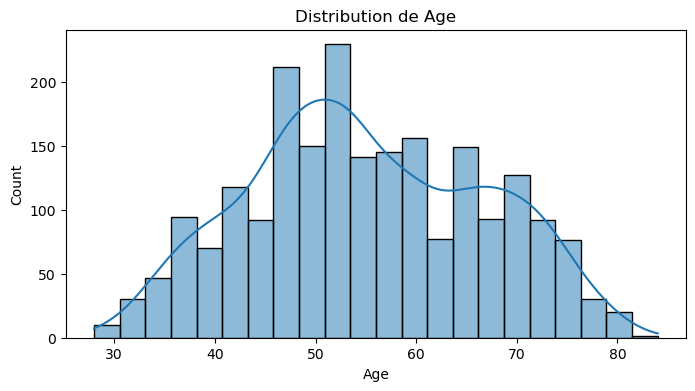

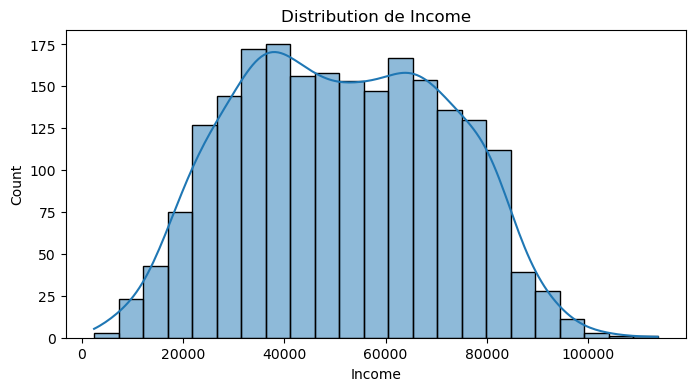

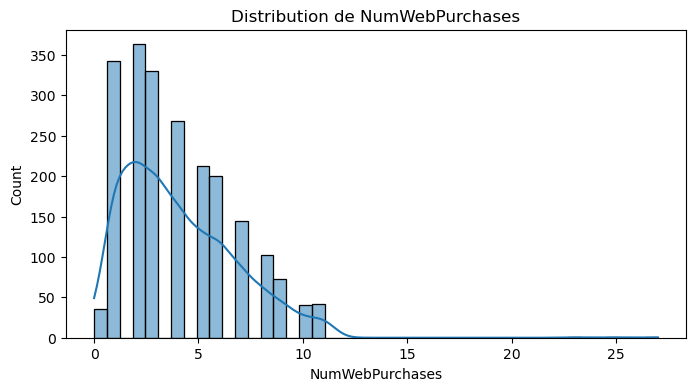

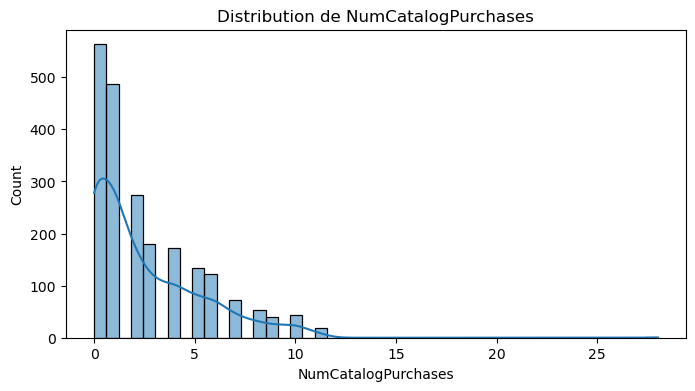

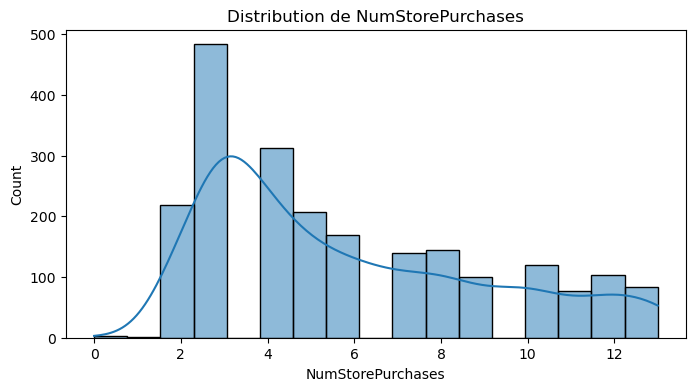

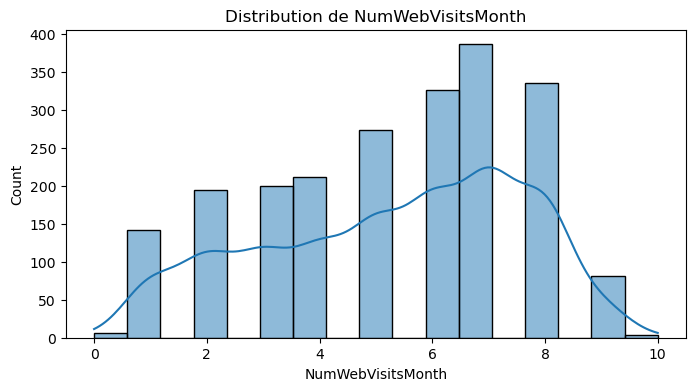

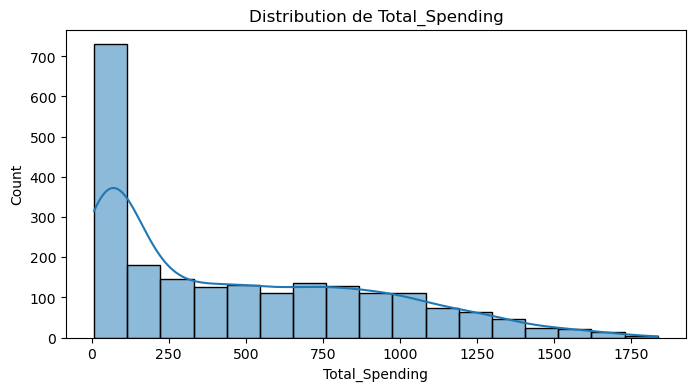

In [125]:
cols = ["Age", "Income", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth", "Total_Spending"] 

for col in cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution de {col}")
    plt.show()

OBSERVATION : 

- L'age s'étend entre 30 et 80 ans mais il y a une forte concentration autour des 50-60 ans. 
- Les income se concentrent principalement entre 20000 et 80000 avec quelques données très supérieures au-delà.
- Les achats sur le web sont peu étendus entre 0 et 11 achats, avec une concentration autour des 2.5 achats environ. 
- Les achats en catalogue sont peu étendus entre 0 et 12 achats, avec une concentration autour des 0 à 1 achat environ. 
- Le nombre d'achat en magasin est très homogène dans la population observée, avec un pic de représentation à 2-3 achats.
- Le nombre de visite web par mois est assez homogène dans la population avec cependant un pic entre 6 et 8 visites mensuelles.
- Enfin la majorité de la population observée à un Total_Spending inférieur à 125, ensuite entre 225 et 1000 c'est assez homogène et puis nous avons des données qui s'étendent faiblement jusqu'à 1750 et plus. 

---

##### ANALYSE BIVARIÉE

In [126]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Years', 'Total_Spending',
       'Total_Accepted_Campaigns'],
      dtype='object')

ANALYSE QUALITATIVE : Pour commencer cette analyse Bivariée, nous observons les variables qualitatives.

<Axes: xlabel='Education'>

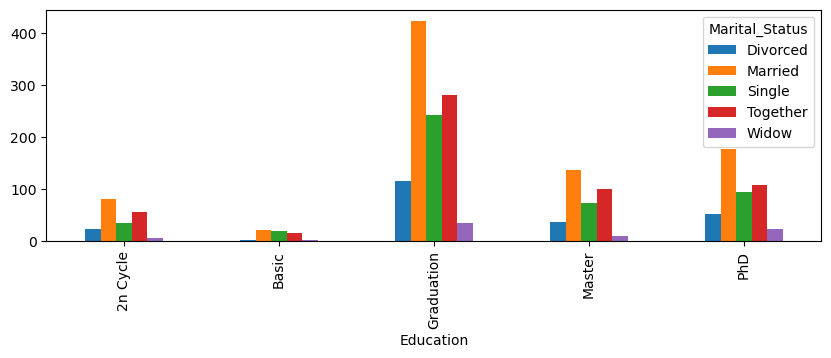

In [127]:
tab=pd.crosstab(df.Education, df.Marital_Status)
tab.plot(kind="bar", figsize=(10,3))

# Conclusion : Les Married sont majoritairement représentés dans chaque catégorie de Education, suivi des Together et des Singles. Il y a peu de population dans les Basic et 2n Cycle. 

ANALYSE NUMÉRIQUES : Passons à l'analyse des données quantitatives : 

<Axes: xlabel='Income', ylabel='Total_Spending'>

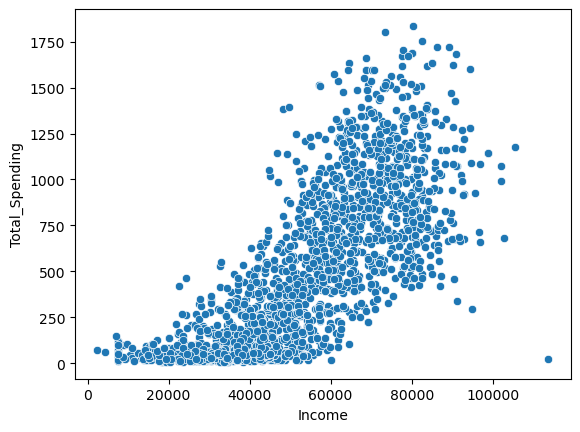

In [128]:
sns.scatterplot(x="Income", y="Total_Spending", data=df) 
# Logiquement, on observe ici que plus les revenus sont élevés, plus les dépenses sont importantes.

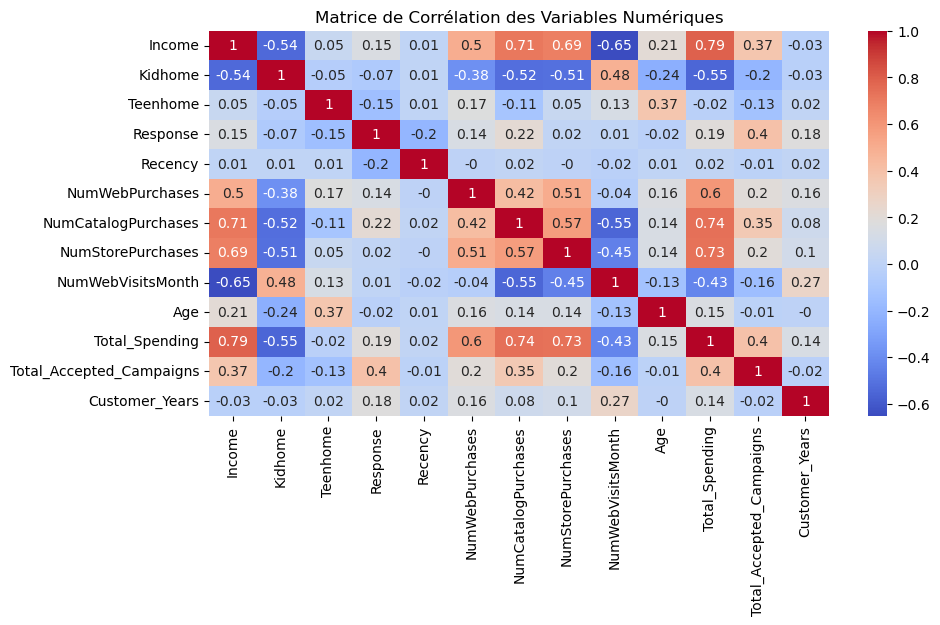

In [129]:
# Matrice de coorélation 

num_cols = ['Income', 'Kidhome', 'Teenhome', 'Response', 'Recency', 'NumWebPurchases', 'NumCatalogPurchases', 
            'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Total_Spending', 'Total_Accepted_Campaigns', "Customer_Years"]

plt.figure(figsize=(10, 5))
corr = df[num_cols].corr().round(2)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice de Corrélation des Variables Numériques")
plt.show()

- Income & Total_Spending - corrélation forte (0.79) : Les clients qui gagnent plus dépensent beaucoup plus. C’est une relation logique et attendue. Les deux variables portent la même information économique.
- Income & NumWebVisitsMonth - corrélation négative forte (-0.65) : Les clients à revenu élevé visitent moins souvent le site web. Interprétation : moins de recherche de promotions, achats plus rapides, comportements plus premium.
- NumWebPurchases, NumCatalogPurchases, NumStorePurchases : Corrélations modérées entre elles (0.3–0.5).
- Total_Accepted_Campaigns : corrélation faible avec tout, les campagnes passées n’expliquent pas beaucoup la réponse actuelle.
- Age - corrélations faibles : Age n’est pas un driver fort du comportement d’achat dans ce dataset. Corrélation faible avec Response.
- Kidhome & Teenhome - corrélation faible avec tout : Les enfants n’expliquent pas beaucoup la réponse marketing. Teenhome est un peu plus informatif que Kidhome.
- Recency : corrélation faible avec tout mais Recency est souvent très utile en marketing (plus récent = plus actif).
- "Customer_Years" - corrélation faible (<0.3) : l'ancienneté du client n'explique pas la réponse. 

ANALYSE QUALITATIFS VS NUMÉRIQUES : Ensuite, comparons les variables qualitatives avec des variables numériques.

In [130]:
from scipy.stats import f_oneway, kruskal

In [131]:
# Question posée : "Est‑ce que les variables numériques varient selon les catégories de Education ou Marital_Status ?”

def analyse_quali_quanti(df, quali_col, quanti_cols):

    categories = df[quali_col].dropna().unique()

    for col in quanti_cols:

        # Préparation des groupes
        groups = [df[df[quali_col] == cat][col].dropna() for cat in categories]

        # ANOVA
        try:
            _, p_anova = f_oneway(*groups)
        except:
            p_anova = None

        # Kruskal
        try:
            _, p_kruskal = kruskal(*groups)
        except:
            p_kruskal = None

        print(f"\n{quali_col} vs {col}")
        print(f"ANOVA p-value   : {p_anova}")
        print(f"Kruskal p-value : {p_kruskal}")

        # Boxplot
        plt.figure(figsize=(7,4))
        sns.boxplot(x=quali_col, y=col, data=df)
        plt.title(f"{col} selon {quali_col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


# Cette fonction permet de récupérer les catégories, de préparer les groupes, séparer les données par catégorie, de	créer les groupes numériques, de faire les tests Anova et Kruskal et enfin d'afficher les p-values et les boxplots.


Education vs Income
ANOVA p-value   : 1.678010089815834e-31
Kruskal p-value : 6.741593538267021e-29


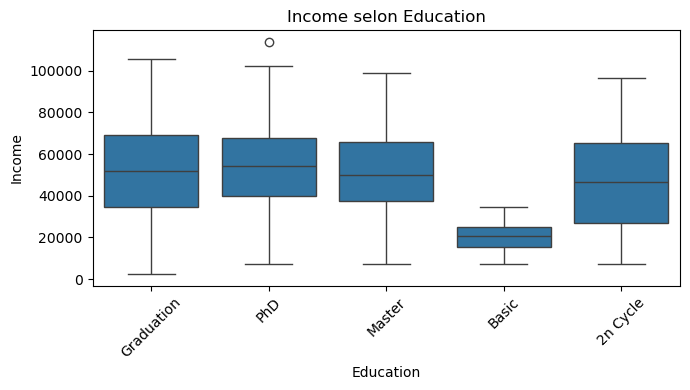


Education vs Kidhome
ANOVA p-value   : 0.07540035013288368
Kruskal p-value : 0.030454628067995156


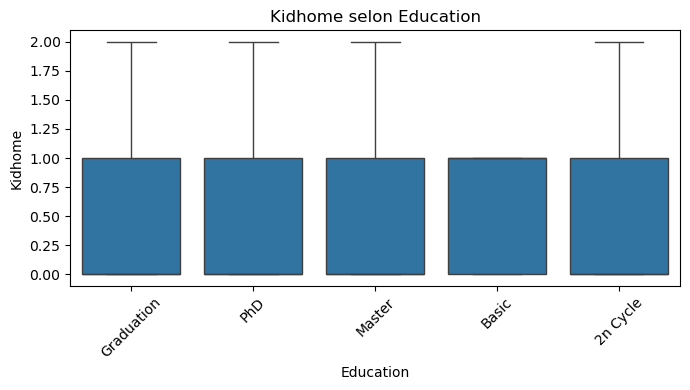


Education vs Teenhome
ANOVA p-value   : 9.763397031320247e-12
Kruskal p-value : 1.5669663981592203e-11


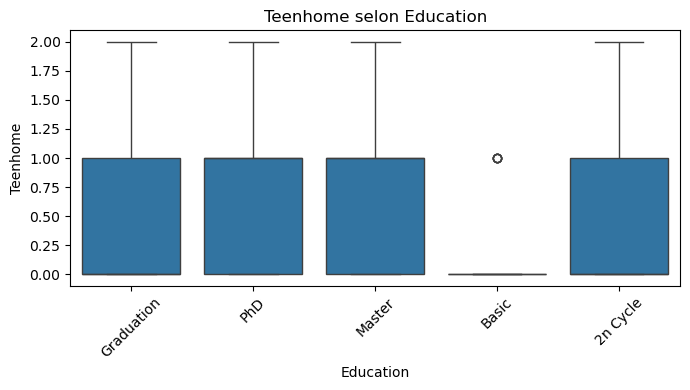


Education vs Recency
ANOVA p-value   : 0.6863781383762224
Kruskal p-value : 0.6857209481389706


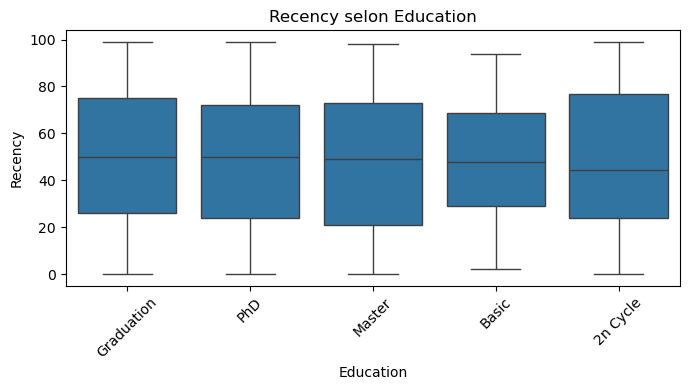


Education vs NumWebPurchases
ANOVA p-value   : 3.1106596436214626e-09
Kruskal p-value : 4.542312877450794e-12


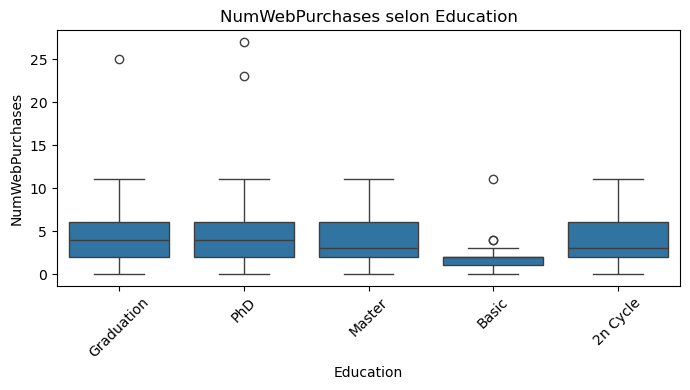


Education vs NumCatalogPurchases
ANOVA p-value   : 1.5584164345214254e-07
Kruskal p-value : 1.0495555883741171e-10


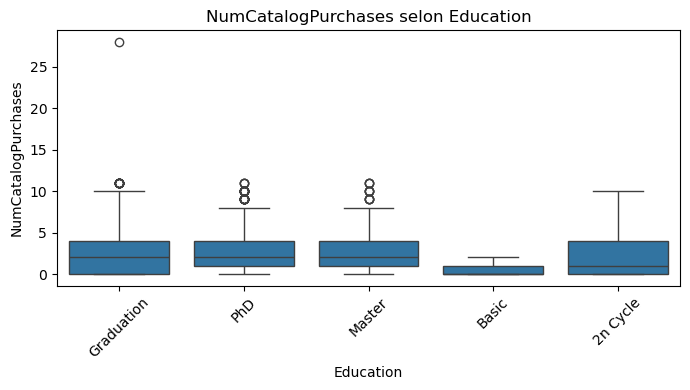


Education vs NumStorePurchases
ANOVA p-value   : 1.5425946806426283e-10
Kruskal p-value : 9.371925007041754e-15


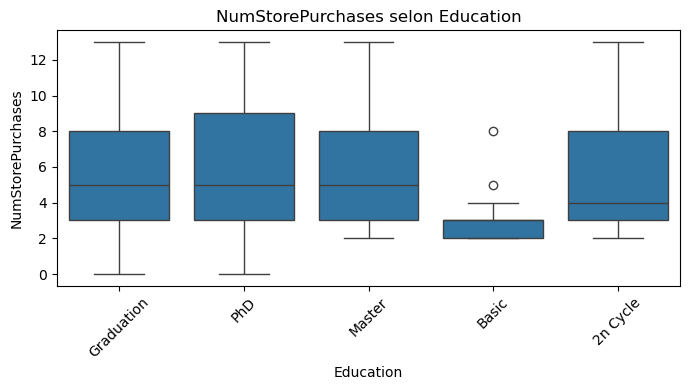


Education vs NumWebVisitsMonth
ANOVA p-value   : 1.1039057182496496e-05
Kruskal p-value : 8.72094512720326e-06


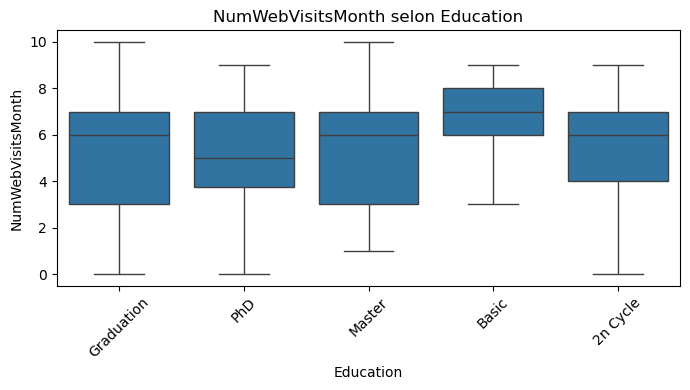


Education vs Age
ANOVA p-value   : 5.4472149069581e-19
Kruskal p-value : 2.6619776443410064e-18


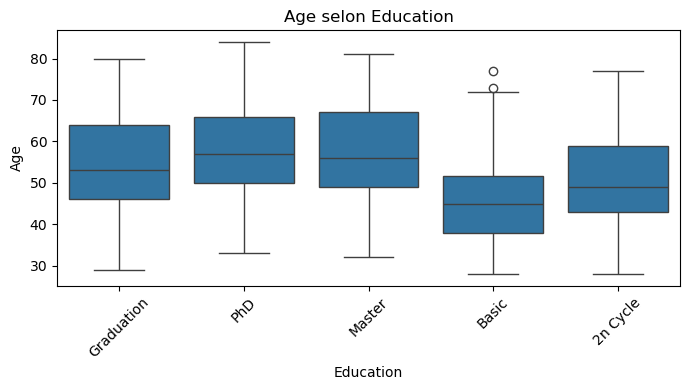


Education vs Total_Spending
ANOVA p-value   : 2.561415286333011e-14
Kruskal p-value : 1.0607842122525533e-15


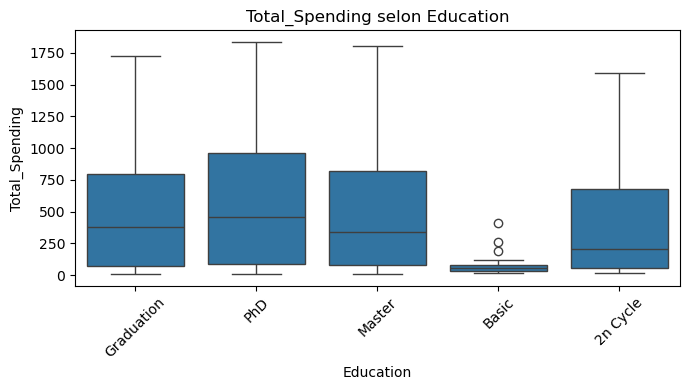


Education vs Total_Accepted_Campaigns
ANOVA p-value   : 0.3546709312947229
Kruskal p-value : 0.39737431902592146


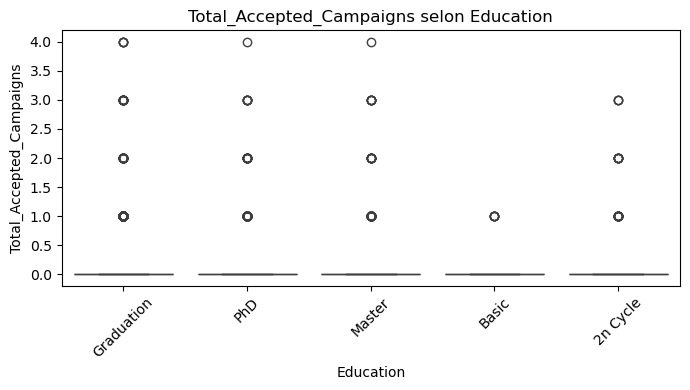


Education vs Customer_Years
ANOVA p-value   : 0.4049362619669933
Kruskal p-value : 0.4183866179878962


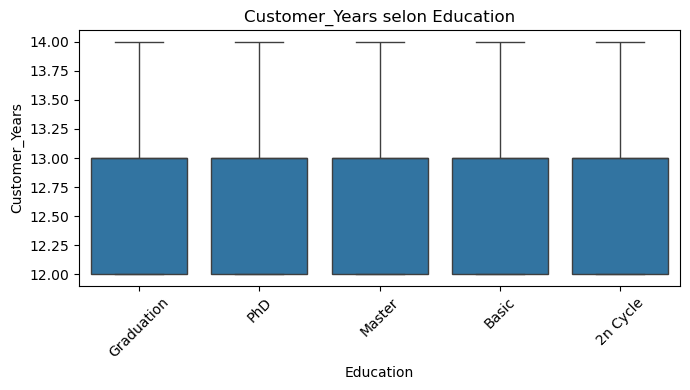


Marital_Status vs Income
ANOVA p-value   : 0.21344079617328396
Kruskal p-value : 0.15415926075613906


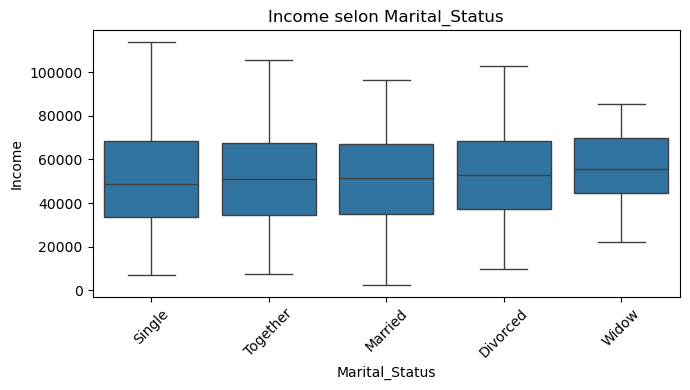


Marital_Status vs Kidhome
ANOVA p-value   : 0.013675876532624054
Kruskal p-value : 0.014408561363079891


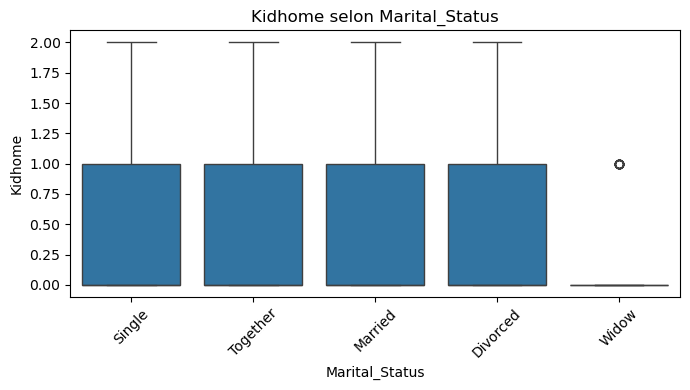


Marital_Status vs Teenhome
ANOVA p-value   : 1.78776771505229e-05
Kruskal p-value : 5.447881827397644e-06


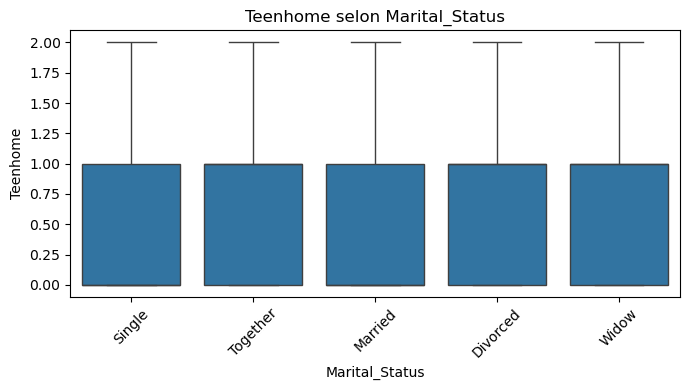


Marital_Status vs Recency
ANOVA p-value   : 0.8133016079218187
Kruskal p-value : 0.8107736995646133


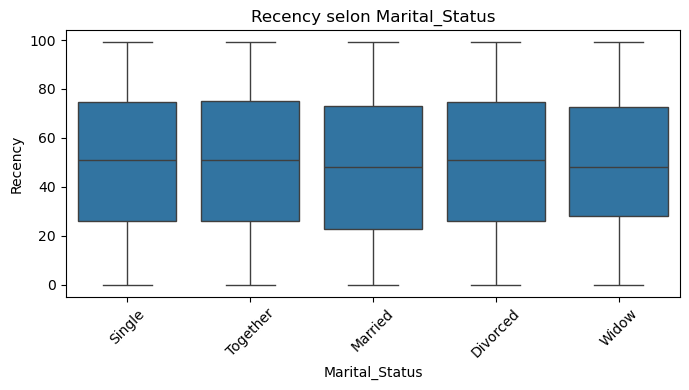


Marital_Status vs NumWebPurchases
ANOVA p-value   : 0.06915117423490993
Kruskal p-value : 0.08351275142012954


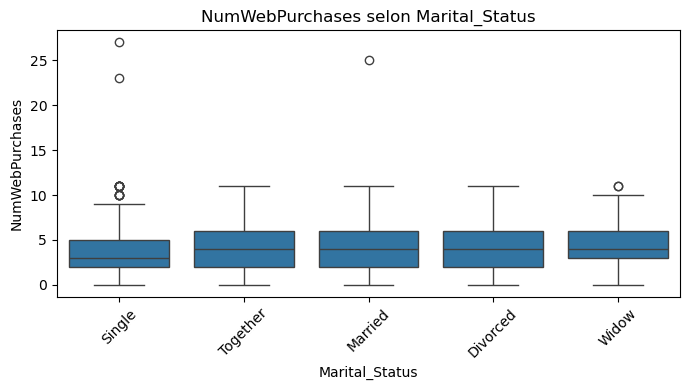


Marital_Status vs NumCatalogPurchases
ANOVA p-value   : 0.23610884123293394
Kruskal p-value : 0.09473864120679049


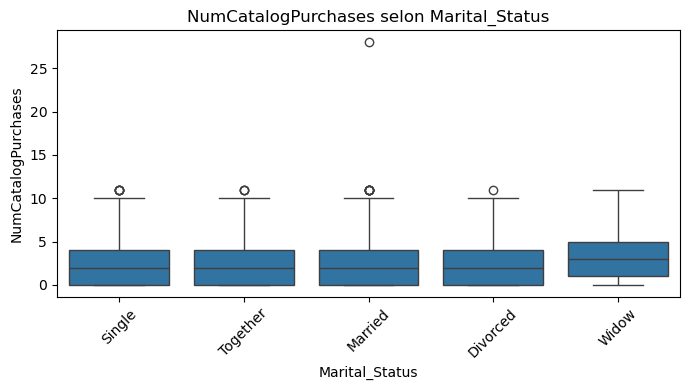


Marital_Status vs NumStorePurchases
ANOVA p-value   : 0.5798695361926157
Kruskal p-value : 0.42112667392076086


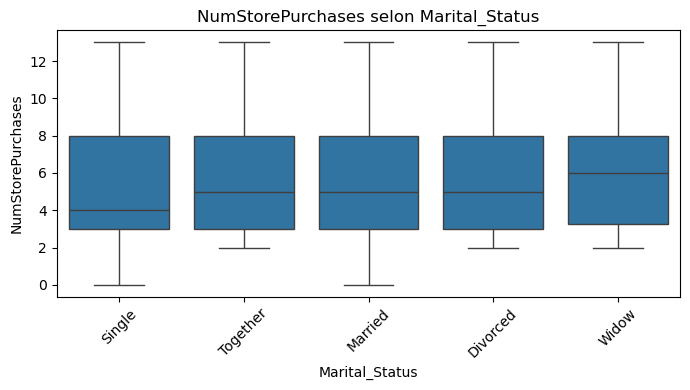


Marital_Status vs NumWebVisitsMonth
ANOVA p-value   : 0.4415553864502747
Kruskal p-value : 0.451092120178998


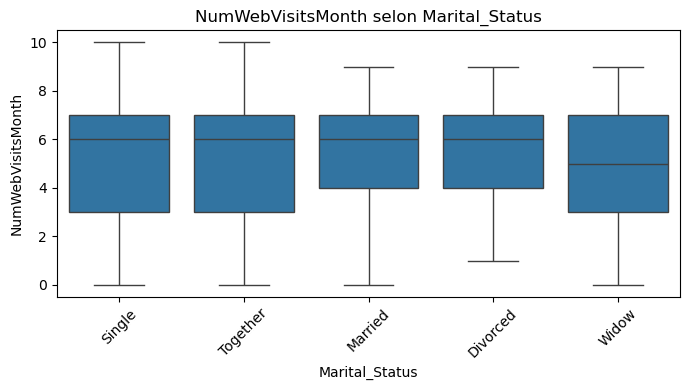


Marital_Status vs Age
ANOVA p-value   : 1.101148851034104e-21
Kruskal p-value : 2.980160806788113e-20


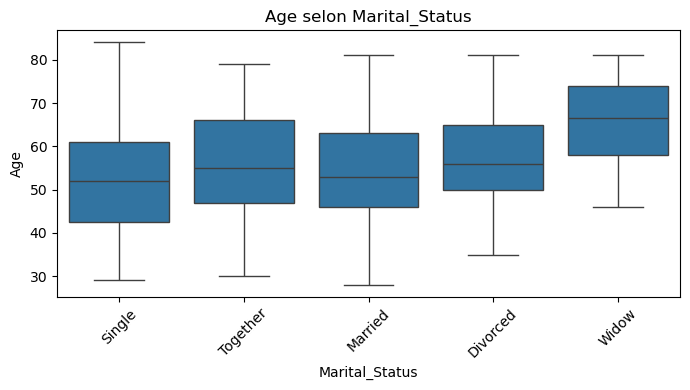


Marital_Status vs Total_Spending
ANOVA p-value   : 0.24629188517438275
Kruskal p-value : 0.2491208622355203


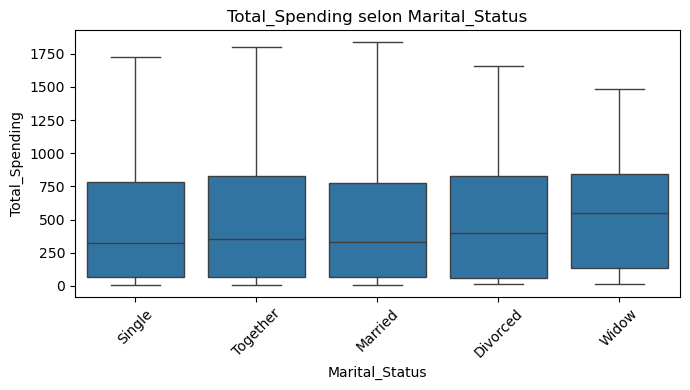


Marital_Status vs Total_Accepted_Campaigns
ANOVA p-value   : 0.944867734544456
Kruskal p-value : 0.9626449598589089


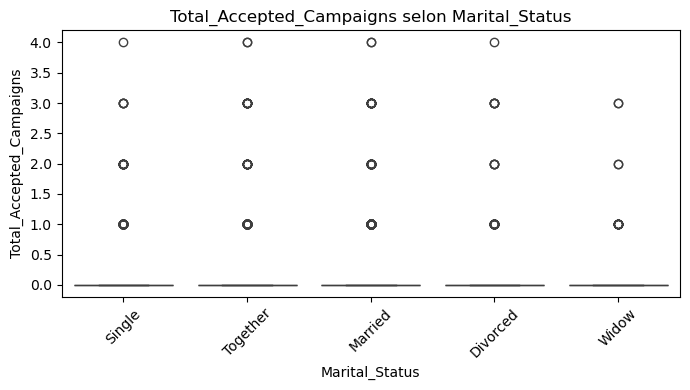


Marital_Status vs Customer_Years
ANOVA p-value   : 0.36508953861085525
Kruskal p-value : 0.45567625943539947


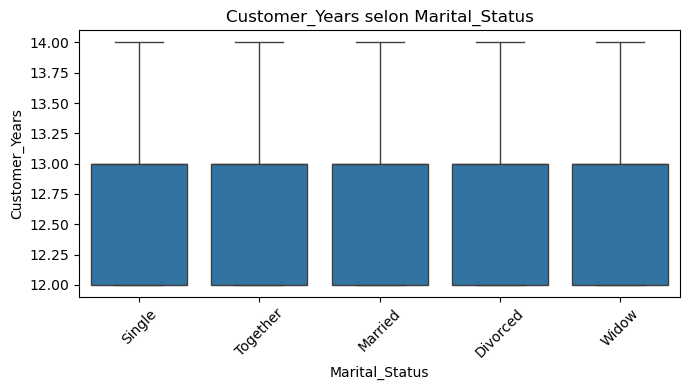

In [132]:
num_cols = [
    'Income', 'Kidhome', 'Teenhome', 'Recency', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
    'Age', 'Total_Spending', 'Total_Accepted_Campaigns', 'Customer_Years'
]

analyse_quali_quanti(df, "Education", num_cols)
analyse_quali_quanti(df, "Marital_Status", num_cols)

On observe que la variable "Education" est une variable très informative. Elle influence les revenus, les dépenses, les comportements d’achat, l’âge, ainsi que la composition du foyer.

La variable "Marital_Status" est beaucoup moins informatif. Il influence seulement : Kidhome, Teenhome et Age

Les variables nuémriques les plus sensibles aux variables qualitatives sont : Income, Age, Total_Spending, NumWebPurchases / Catalog / Store et Teenhome

Les variables numériques les moins significatives sont : 
- Recency : Le temps depuis le dernier achat ne dépend pas de l’éducation et ne change pas selon le statut marital.
- Total_Accepted_Campaigns : Le nombre de campagnes acceptées ne varie pas selon l’éducation ou le statut marital.
- Customer_Years : l'ancieneté ne joue pas selon l'éducation ou le statut marital. Cela s'explique par la pauvreté en diversité de l'échantillon de populaiton (entre 12 et 14 ans).

ANALYSE AVEC LA VARIABLE CIBLE : Nous allons faire une analyse avec la variable cible "Response".

In [133]:
# Variables numériques vs cible (ANOVA)

num_cols = ['Income', 'Kidhome', 'Teenhome', 'Recency', 'NumWebPurchases', 'NumCatalogPurchases', 
            'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Total_Spending', 'Total_Accepted_Campaigns', 'Customer_Years']

from scipy.stats import f_oneway

group0 = df[df["Response"] == 0]
group1 = df[df["Response"] == 1]

for col in num_cols:
    stat, p = f_oneway(group0[col], group1[col])
    print(f"{col} : p-value = {p}")


# p > 0.05 pour les variables 'NumStorePurchases', 'NumWebVisitsMonth' et 'Age', donc leur relation avec la variable cible 'Response' n'est pas significative (on accepte H0). 
# les autres variables sont significatives sauf Kidhome qui est modérémment significatif. 

Income : p-value = 2.5143999253991157e-12
Kidhome : p-value = 0.0022848742420048776
Teenhome : p-value = 1.5194423560999287e-12
Recency : p-value = 2.2557574792088604e-20
NumWebPurchases : p-value = 4.176848287431238e-11
NumCatalogPurchases : p-value = 3.70216438957262e-25
NumStorePurchases : p-value = 0.33479229452291115
NumWebVisitsMonth : p-value = 0.5014493441921446
Age : p-value = 0.47531924540063675
Total_Spending : p-value = 1.7967980406330755e-19
Total_Accepted_Campaigns : p-value = 2.119284525991134e-83
Customer_Years : p-value = 9.461773124546904e-18


In [134]:
# Variables catégorielles vs cible (test Chi²)

quali_cols = ['Education', 'Marital_Status', 'Complain']

from scipy.stats import chi2_contingency

for col in quali_cols:
    contingency = pd.crosstab(df[col], df["Response"])
    chi2, p, _, _ = chi2_contingency(contingency)
    print(f"{col} : p-value = {p}")

# p < 0.05 donc la relation des variables 'Education', 'Marital_Status' avec la variable cible 'Response' est significative (on rejette H0). 
# p > 0.05 donc la relation de la variable Complain (p-value = 1.0) n'est pas significative avec Response. 

Education : p-value = 0.0006629243946968111
Marital_Status : p-value = 1.587980682452083e-09
Complain : p-value = 1.0


In [135]:
pd.crosstab(df["Education"], df["Response"], normalize="index")

# La population qui est a le plus accepté la dernière offre sont les PhD (20%) contre 3% chez les Basic, 15% chez les Master et parmis notre population majoritairement représentée, nous avons un taux de réponse positive à 13%.

Response,0,1
Education,,
2n Cycle,0.888889,0.111111
Basic,0.962963,0.037037
Graduation,0.868733,0.131267
Master,0.851541,0.148459
PhD,0.800885,0.199115


In [136]:
pd.crosstab(df["Marital_Status"], df["Response"], normalize="index")

# les populations les plus favorables sont Divorced, Single, Widow. 
# Together est la population la moins favorable.

Response,0,1
Marital_Status,,
Divorced,0.796460,0.203540
Married,0.889021,0.110979
Single,0.781857,0.218143
Together,0.901257,0.098743
Widow,0.783784,0.216216


Les variables suivantes montrent des différences très nettes entre les clients qui répondent et ceux qui ne répondent pas, elles influencent fortement la probabilité de réponse : 
- Income (p = 2.5e‑12)
- Teenhome (p = 1.5e‑12)
- Recency (p = 2.2e‑20)
- NumWebPurchases (p = 4.1e‑11)
- NumCatalogPurchases (p = 3.7e‑25)
- Total_Spending (p = 1.8e‑19)
- Total_Accepted_Campaigns (p = 2.1e‑83)
- Education (p = 0.00066)
- Marital_Status (p = 1.58e‑09)
- Customer_Years (p = 4.869172228625401e-18)


La variable Kidhome (p = 0.00228) a un effet réel mais plus faible. En d'autres termes, le nombre d’enfants au foyer influence légèrement la réponse, mais beaucoup moins que Teenhome.

À l'inverse, les variables NumStorePurchases (p = 0.334), NumWebVisitsMonth (p = 0.501), Age (p = 0.475) et Complain (p = 1.0) ne montrent pas de différence statistique entre les groupes Response = 0 et 1.

---

##### ANALYSE MULTIVARIÉE

In [137]:
# Variables numériques pertinentes selon mon analyse bivariée : 

num_cols = [
    "Income", "Teenhome", "Recency", "NumWebPurchases",
    "NumCatalogPurchases", "Total_Spending", "Total_Accepted_Campaigns", "Customer_Years"
]


MANOVA

In [138]:
from statsmodels.multivariate.manova import MANOVA

In [139]:
formula_mancova = " + ".join(num_cols)

In [140]:
# MANOVA pour Education

manova_ed = MANOVA.from_formula(
    f"{formula_mancova} ~ Education", data=df
    )

print(manova_ed.mv_test())

                    Multivariate linear model
                                                                  
------------------------------------------------------------------
       Intercept         Value  Num DF   Den DF   F Value   Pr > F
------------------------------------------------------------------
          Wilks' lambda  0.0233 8.0000 2146.0000 11267.4337 0.0000
         Pillai's trace  0.9767 8.0000 2146.0000 11267.4337 0.0000
 Hotelling-Lawley trace 42.0035 8.0000 2146.0000 11267.4337 0.0000
    Roy's greatest root 42.0035 8.0000 2146.0000 11267.4337 0.0000
------------------------------------------------------------------
                                                                  
------------------------------------------------------------------
          Education        Value   Num DF   Den DF  F Value Pr > F
------------------------------------------------------------------
             Wilks' lambda 0.8949 32.0000 7915.6521  7.5598 0.0000
            Pill

Les clients n’ayant pas le même niveau d’éducation présentent des profils multivariés différents : revenus différents, dépenses différentes, comportements d’achat différents, âge différent, composition du foyer différente.

Donc, Education est une variable explicative forte et multidimensionnelle.

In [141]:
# MANOVA pour Marital_Status

manova_ms = MANOVA.from_formula(
    f"{formula_mancova} ~ Marital_Status", data=df
    )

print(manova_ms.mv_test())

                    Multivariate linear model
                                                                  
------------------------------------------------------------------
       Intercept         Value  Num DF   Den DF   F Value   Pr > F
------------------------------------------------------------------
          Wilks' lambda  0.0205 8.0000 2146.0000 12818.9569 0.0000
         Pillai's trace  0.9795 8.0000 2146.0000 12818.9569 0.0000
 Hotelling-Lawley trace 47.7874 8.0000 2146.0000 12818.9569 0.0000
    Roy's greatest root 47.7874 8.0000 2146.0000 12818.9569 0.0000
------------------------------------------------------------------
                                                                  
------------------------------------------------------------------
        Marital_Status     Value   Num DF   Den DF  F Value Pr > F
------------------------------------------------------------------
             Wilks' lambda 0.9786 32.0000 7915.6521  1.4521 0.0478
            Pill

La MANOVA montre que Marital_Status a un effet global, mais petit. L’effet est probablement dû à Age, Kidhome, Teenhome. Les autres variables quantitatives ne varient presque pas selon Marital_Status

Donc, c’est un effet multivarié faible mais réel.

MANCOVA

In [142]:
# Mancova avec la variable "Age" car elle influence Education, Marital_Status et plusieurs variables quantitatives (Income, Spending, Recency, Teenhome, etc).

formula_mancova = " + ".join(num_cols)

# MANCOVA Education en contrôlant Age

mancova_ed = MANOVA.from_formula(
    f"{formula_mancova} ~ Education + Age", data=df)

print(mancova_ed.mv_test())

                    Multivariate linear model
                                                                 
-----------------------------------------------------------------
       Intercept         Value  Num DF   Den DF   F Value  Pr > F
-----------------------------------------------------------------
          Wilks' lambda  0.0637 8.0000 2145.0000 3943.6387 0.0000
         Pillai's trace  0.9363 8.0000 2145.0000 3943.6387 0.0000
 Hotelling-Lawley trace 14.7082 8.0000 2145.0000 3943.6387 0.0000
    Roy's greatest root 14.7082 8.0000 2145.0000 3943.6387 0.0000
-----------------------------------------------------------------
                                                                 
-----------------------------------------------------------------
         Education        Value   Num DF   Den DF  F Value Pr > F
-----------------------------------------------------------------
            Wilks' lambda 0.9168 32.0000 7911.9643  5.8921 0.0000
           Pillai's trace 0.08

Observation : Education reste significatif même après avoir retiré l’effet de Age et Age influence très fortement les variables quantitatives. Donc Education est un vrai facteur explicatif, pas un artefact dû à l’âge.

In [143]:
# MANCOVA Marital_Status en contrôlant Age

mancova_ms = MANOVA.from_formula(
    f"{formula_mancova} ~ Marital_Status + Age", data=df)

print(mancova_ms.mv_test())


                    Multivariate linear model
                                                                 
-----------------------------------------------------------------
       Intercept         Value  Num DF   Den DF   F Value  Pr > F
-----------------------------------------------------------------
          Wilks' lambda  0.0713 8.0000 2145.0000 3490.4922 0.0000
         Pillai's trace  0.9287 8.0000 2145.0000 3490.4922 0.0000
 Hotelling-Lawley trace 13.0182 8.0000 2145.0000 3490.4922 0.0000
    Roy's greatest root 13.0182 8.0000 2145.0000 3490.4922 0.0000
-----------------------------------------------------------------
                                                                 
-----------------------------------------------------------------
       Marital_Status     Value   Num DF   Den DF  F Value Pr > F
-----------------------------------------------------------------
            Wilks' lambda 0.9897 32.0000 7911.9643  0.6970 0.8988
           Pillai's trace 0.01

L’effet multivarié de Marital_Status disparaît complètement. Cela signifie que l’effet observé en MANOVA était entièrement dû à Age. 
Donc, Marital_Status n’a pas d’effet propre sur les comportements d’achat. L’effet apparent était en réalité causé par l’âge des clients.

---

##### MEDIATION

In [144]:
import statsmodels.api as sm
from statsmodels.stats.mediation import Mediation
from statsmodels.formula.api import ols, logit

In [145]:
# Étape 1 : Income (X) prédit Total_Spending (M)

model_a = ols('Total_Spending ~ Income', data=df).fit()
a = model_a.params['Income']

# Étape 2 : Income (X) et Total_Spending (M) prédisent Response (Y)
# Response est binaire → régression logistique

model_b_c_prime = logit('Response ~ Income + Total_Spending', data=df).fit()
b = model_b_c_prime.params['Total_Spending']
c_prime = model_b_c_prime.params['Income']

# Étape 3 : Income (X) prédit Response (Y) seul

model_total = logit('Response ~ Income', data=df).fit()
c_total = model_total.params['Income']

# Calcul des effets

indirect_effect = a * b
direct_effect = c_prime
total_effect = c_total

indirect_effect, direct_effect, total_effect

Optimization terminated successfully.
         Current function value: 0.394901
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.401002
         Iterations 6


(1.8236894270372444e-05, 2.418213406555246e-06, 2.145008966611537e-05)

Effet indirect = 1.8237e‑05 : C’est la partie de l’effet de Income sur Response qui passe par Total_Spending. 
Donc, la majorité de l’effet de Income passe par Spending. Les clients riches répondent plus parce qu’ils dépensent plus.

Effet direct = 2.4182e‑06 : C’est l’effet de Income sur Response indépendamment de Spending. Il est très faible comparé à l’effet indirect.

Effet total = 2.1450e‑05 : C’est l’effet global de Income → Response. 
Donc, plus le revenu augmente, plus la probabilité de réponse augmente.  

In [146]:
# Étape 1 : Income (X) prédit Customer_Years (M)
model_a = ols('Customer_Years ~ Income', data=df).fit()
a = model_a.params['Income']

# Étape 2 : Income (X) et Customer_Years (M) prédisent Response (Y)
model_b_c_prime = logit('Response ~ Income + Customer_Years', data=df).fit()
b = model_b_c_prime.params['Customer_Years']
c_prime = model_b_c_prime.params['Income']

# Étape 3 : Income (X) prédit Response (Y) seul
model_total = logit('Response ~ Income', data=df).fit()
c_total = model_total.params['Income']

# Calcul des effets
indirect_effect = a * b
direct_effect = c_prime
total_effect = c_total

indirect_effect, direct_effect, total_effect

Optimization terminated successfully.
         Current function value: 0.383159
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.401002
         Iterations 6


(-8.840427095055118e-07, 2.317257941408801e-05, 2.145008966611537e-05)

Effet indirect = -8.33e‑07 : Customer_Years n’est pas un médiateur. Il n’explique absolument pas la relation entre Income et Response.

Effet direct = 2.312e‑05 : Cela signifie que Income influence Response directement, sans passer par Customer_Years.

Effet total = 2.145e‑05 : C’est l’effet global de Income → Response. 
Donc, plus le revenu augmente, plus la probabilité de réponse augmente.  

---

##### VIF - Variance Inflation Factor

Nous allons maintenant pouvoir trier nos variables numériques à l'aide de la méthode VIF, pour éliminer les variables redondantes, s'il y en a. 

In [147]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

In [148]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Years', 'Total_Spending',
       'Total_Accepted_Campaigns'],
      dtype='object')

In [149]:
# Sélection des variables quantitatives
num_cols =['ID','Year_Birth', 'Income', 'Kidhome',
       'Teenhome', 'Recency', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Total_Spending', 'Customer_Years',
       'Total_Accepted_Campaigns']

df_vif = df[num_cols]

# Calcul des VIF
vif_data = pd.DataFrame()
vif_data["features"] = df_vif.columns
vif_data["VIF Factor"] = [VIF(df_vif.values, i) for i in range(df_vif.shape[1])]
vif_data["Precision"] = [1 - 1/VIF(df_vif.values, i) for i in range(df_vif.shape[1])]

vif_data.sort_values(by="VIF Factor", ascending=False)

# La seule redondance est Year_Birth, ce qui est logique puisque nous avons créé la variable "Age" à partir de Year_birth. 

,features,VIF Factor,Precision
1,Year_Birth,474.844979,0.997894
12,Age,28.110648,0.964426
13,Total_Spending,4.717223,0.788011
2,Income,4.653034,0.785086
9,NumWebVisitsMonth,2.946076,0.660565
7,NumCatalogPurchases,2.813342,0.644551
8,NumStorePurchases,2.554172,0.608484
6,NumWebPurchases,2.023932,0.505912
3,Kidhome,1.760847,0.432092
15,Total_Accepted_Campaigns,1.464804,0.317315


In [150]:
df = df.drop(['ID', 'Year_Birth', 'Dt_Customer'], axis=1) # suppression de la variable redondante 'Year_Birth', la variable de date inutile 'Dt_Customer' et de 'ID' car inutile dans notre analyse. 

## PARTIE 3 : Segmentation clients

Construire une segmentation cohérente, interprétable et exploitable. Le choix de la méthode est libre,
mais il doit être expliqué et défendu.

---

##### Sélectionner les variables pertinentes / Tester et justifier la méthode choisie

In [151]:
df.columns

Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Years', 'Total_Spending', 'Total_Accepted_Campaigns'],
      dtype='object')

Selon les analyses précédentes, voici les variables que nous sélectionnons : 

**1. Valeur client**
- Income
- Total_Spending
- Total_Accepted_Campaigns

**2. Comportements d’achat**
- NumWebPurchases
- NumCatalogPurchases
- NumStorePurchases
- NumWebVisitsMonth
- Recency

**3. Profil client**
- Age
- Customer_Years
- Teenhome
- Kidhome

**Les variables à exclure**
- Response (à utiliser comme variable descriptive, pas comme variable de clustering)
- Education (trop catégorielle, peu discriminante)
- Marital_Status (non significative après MANCOVA)
- Complain (rare → bruit)

In [152]:
vars_segmentation = [
    'Income', 'Total_Spending', 'Total_Accepted_Campaigns',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth', 'Recency',
    'Age', 'Customer_Years', 'Kidhome', 'Teenhome'
]

df_seg = df[vars_segmentation].copy()

In [153]:
# Standardisation

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_seg)

---

##### Déterminer un nombre de segments cohérent

In [154]:
pip install -U yellowbrick

Note: you may need to restart the kernel to use updated packages.


In [155]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt

Utilisation de la méthode Elbow

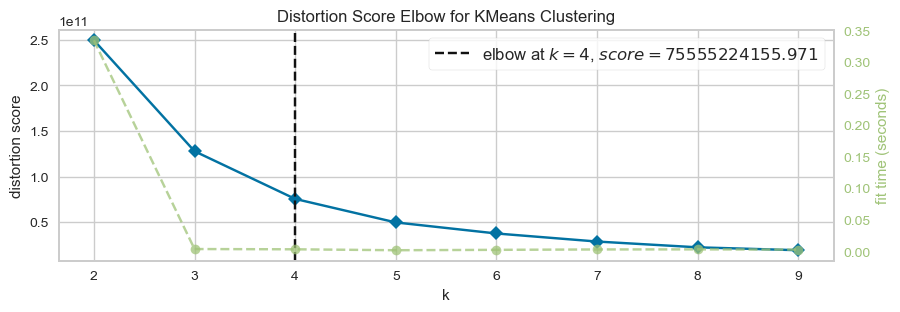

In [156]:
plt.figure(figsize=(10, 3))

model = KMeans()  #on definie une instance
visualizer = KElbowVisualizer(model, k=(2, 10), force_model=True)  #CHOISIR ENTRE 2,3,4.,,,10 cluster
visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show();        # Finalize and render the figure

Utilisation de la méthode Silhouette Score 

In [160]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

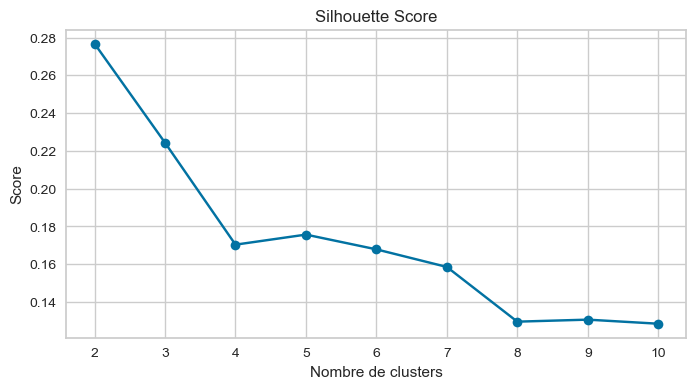

[0.2767326308206687,
 0.22431276084125853,
 0.17036852453506543,
 0.17569555933400252,
 0.16788009725637018,
 0.15856585056491448,
 0.12961161973583915,
 0.1306748591463817,
 0.128516618444829]

In [161]:
# Silhouette score

K_range = range(2, 11)  # de 2 à 10 clusters (on évite 1 pour silhouette)

sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(8,4))
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Nombre de clusters")
plt.ylabel("Score")
plt.show()

sil_scores

CONCLUSION : 4 clusters est le meilleur compromis entre simplicité et qualité.

k = 4 est un bon choix

k = 3 ou 5 seraient possibles, mais moins cohérents

k = 2 est trop pauvre pour segmenter des clients

---

##### Déterminer les segments finaux 

In [162]:
# Modèle final K-Means

k_final = 4
kmeans_final = KMeans(n_clusters=k_final, random_state=42)
df['Segment'] = kmeans_final.fit_predict(X_scaled)

In [163]:
# Profil moyen de chaque segment

segment_profile = df.groupby('Segment')[vars_segmentation].mean().round(2)
segment_profile

,Income,Total_Spending,Total_Accepted_Campaigns,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Recency,Age,Customer_Years,Kidhome,Teenhome
Segment,,,,,,,,,,,,
0,29898.92,108.78,0.10,2.41,0.55,3.23,6.88,48.89,45.48,12.75,0.87,0.00
1,76365.89,947.91,0.77,4.74,6.07,8.32,2.45,49.90,55.00,12.66,0.04,0.07
2,60599.07,762.62,0.22,6.78,3.47,8.28,5.56,48.56,59.51,12.98,0.13,0.92
3,41777.87,128.10,0.08,2.35,0.74,3.66,5.88,49.11,60.23,12.65,0.71,0.97


---

##### Visualisation des segments

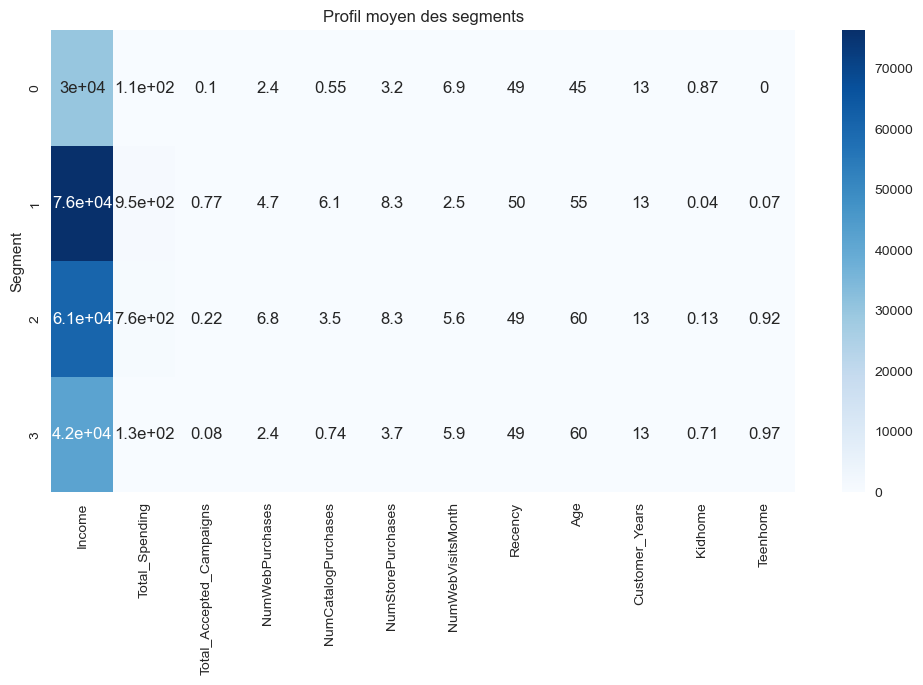

In [164]:
plt.figure(figsize=(12,6))
sns.heatmap(segment_profile, annot=True, cmap="Blues")
plt.title("Profil moyen des segments")
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


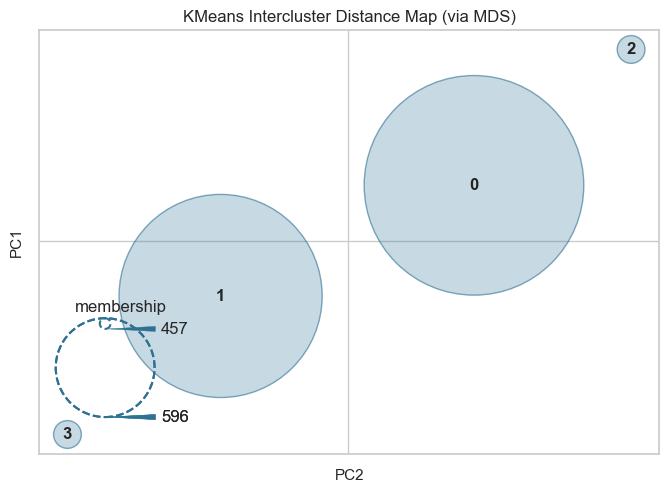

In [165]:
from yellowbrick.cluster import InterclusterDistance

# Instantiate the clustering model and visualizer
model = KMeans(4) 
visualizer = InterclusterDistance(model, force_model=True)

visualizer.fit(X)        # vous avez le choix d'utiliser X_brut, X_standardisé
visualizer.show();        # Finalize and render the figure

---

##### Qualifier chaque segment en langage métier : valeur, potentiel, sensibilité campagne, type de comportement

In [166]:
for s in range(k_final):
    print(f"\n===== SEGMENT {s} =====")
    print(segment_profile.loc[s])


===== SEGMENT 0 =====
Income                      29898.92
Total_Spending                108.78
Total_Accepted_Campaigns        0.10
NumWebPurchases                 2.41
NumCatalogPurchases             0.55
NumStorePurchases               3.23
NumWebVisitsMonth               6.88
Recency                        48.89
Age                            45.48
Customer_Years                 12.75
Kidhome                         0.87
Teenhome                        0.00
Name: 0, dtype: float64

===== SEGMENT 1 =====
Income                      76365.89
Total_Spending                947.91
Total_Accepted_Campaigns        0.77
NumWebPurchases                 4.74
NumCatalogPurchases             6.07
NumStorePurchases               8.32
NumWebVisitsMonth               2.45
Recency                        49.90
Age                            55.00
Customer_Years                 12.66
Kidhome                         0.04
Teenhome                        0.07
Name: 1, dtype: float64

===== SEGMENT 2 =

**Segment 1 : très haut Income + très haut Spending**
- Ce sont clairement les Premium  
- Ils ont aussi le plus haut nombre d’achats catalogues et magasin
- Très forte sensibilité aux campagnes (0.77)

**Segment 2 : Spending élevé + achats web élevés**
- Ce sont les Opportunistes Digitaux  
- Income élevé, mais moins que les Premium
- Très actifs en web (6.78 web purchases)

**Segment 0 : faible Income + faible Spending**
- Ce sont les Traditionnels à faible valeur  
- Beaucoup de visites web mais peu d’achats
- Recency élevée → clients peu actifs

**Segment 3 : faible Spending + âge élevé**
- Ce sont les Seniors à faible valeur  
- Beaucoup de visites web mais peu d’achats
- Très faible réponse aux campagnes


Les écarts sont suffisamment marqués pour justifier une segmentation :

- Income varie de 30k → 76k
- Spending varie de 108 → 948
- WebPurchases varie de 2.4 → 6.8
- CatalogPurchases varie de 0.55 → 6.07
- StorePurchases varie de 3.2 → 8.3
- Response varie de 0.08 → 0.77

Les clusters sont bien séparés
- Pas de chevauchement massif
- Distances claires entre les groupes

- Les clusters 1 et 2 sont les plus gros
- Normal : ce sont les comportements les plus fréquents
- Les clusters 0 et 3 sont plus petits mais cohérents

- Aucun cluster n’est “écrasé” ou “absorbé” : Preuve que k=4 est un bon choix


## PARTIE 4 : KPI métier et lecture décisionnelle

Transformer les résultats analytiques en indicateurs directement exploitables par un décideur
marketing. Les étudiants devront proposer des KPI simples et, si pertinent, des KPI composites.

• Taux de réponse global et par segment.

• Revenu moyen et dépense moyenne par segment.

• Score de valeur client ou de potentiel marketing.

• Indicateurs synthétiques destinés au pilotage mensuel ou trimestriel.

---

##### Taux de réponse global et par segment

In [167]:
# Taux de réponse global
taux_global = df['Response'].mean()

# Taux de réponse par segment
taux_par_segment = df.groupby('Segment')['Response'].mean().round(3)

taux_global, taux_par_segment

(0.14411492122335495,
 Segment
 0    0.126
 1    0.283
 2    0.116
 3    0.071
 Name: Response, dtype: float64)

**Segment 1 — Ultra‑réactif**
Avec 28.3%, ce segment répond 2 fois plus que la moyenne.
- C’est ton cœur de cible marketing.
- Chaque campagne envoyée à ce segment a un ROI élevé.

**Segments 0 et 2 — Réactivité moyenne à faible**
Autour de 11–12%, ils sont proches de la moyenne.
- Ils réagissent, mais seulement si l’offre est pertinente.
- Ce sont des segments à optimiser, pas à abandonner.

**Segment 3 — Très faible réactivité**
Avec 7.1%, ce segment est quasi insensible aux campagnes.
- Il faut éviter de les cibler massivement.
- Préférer des actions de nurturing ou de réactivation.

CONCLUSION : Le segment 1 est le seul véritablement rentable en marketing direct.

---

##### Revenu moyen et dépense moyenne par segment

In [168]:
revenu_par_segment = df.groupby('Segment')['Income'].mean().round(0)
depense_par_segment = df.groupby('Segment')['Total_Spending'].mean().round(0)

revenu_par_segment, depense_par_segment

(Segment
 0    29899.0
 1    76366.0
 2    60599.0
 3    41778.0
 Name: Income, dtype: float64,
 Segment
 0    109.0
 1    948.0
 2    763.0
 3    128.0
 Name: Total_Spending, dtype: float64)

Revenu moyen (Income)
- Segment 1 : 76 366 €
- Segment 2 : 60 599 €
- Segment 3 : 41 778 €
- Segment 0 : 29 899 €

Dépense moyenne (Total_Spending)
- Segment 1 : 948 €
- Segment 2 : 763 €
- Segment 3 : 128 €
- Segment 0 : 109 €

---

##### Score de valeur client ou potentiel marketing

Création d'un KPI composite qui combine : Valeur actuelle (spending), Potentiel (income), Engagement (response) et Activité (web visits)

In [169]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# On scale toutes les colonnes nécessaires d’un coup
cols_to_scale = ['Total_Spending', 'Income', 'NumWebVisitsMonth']
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Score composite
df['Score_Valeur'] = (
    0.4 * df_scaled['Total_Spending'] +
    0.3 * df_scaled['Income'] +
    0.2 * df['Response'] +
    0.1 * df_scaled['NumWebVisitsMonth']
) * 100

df.groupby('Segment')['Score_Valeur'].mean().round(1)


Segment
0    19.0
1    48.6
2    40.1
3    20.5
Name: Score_Valeur, dtype: float64

**Segment 1 — Score 48.6 → Les Premium**

- Très haut revenu
- Très forte dépense
- Très bon taux de réponse
- Activité digitale correcte

Ce sont tes clients VIP. Ils génèrent la majorité de la valeur et réagissent très bien aux campagnes.
C’est le segment à prioriser dans toutes les actions marketing.

**Segment 2 — Score 40.1 → Les Digitaux à fort potentiel**

- Revenu élevé
- Dépense élevée
- Activité web forte
- Taux de réponse moyen

Ils ont un potentiel énorme. Avec un meilleur engagement, ils pourraient rejoindre les Premium.
C’est un segment à travailler, notamment via des campagnes digitales personnalisées.

**Segment 3 — Score 20.5 → Les Seniors à faible valeur**

- Revenu moyen
- Dépense faible
- Taux de réponse très faible
- Activité web modérée

Segment peu rentable. Il ne faut pas les cibler massivement.
À privilégier pour des actions de fidélisation douce, pas pour des campagnes coûteuses.

**Segment 0 — Score 19.0 → Les Jeunes / ménages modestes**

- Revenu faible
- Dépense faible
- Taux de réponse moyen
- Activité web élevée

Faible valeur actuelle, mais potentiel long terme. Ce sont souvent des clients en début de cycle de vie.
À nourrir progressivement, sans investissement marketing lourd.

## PARTIE 5 : Dashboard décisionnel

Construire un simple dashboard ou applicatif qui permette à un décideur de lire rapidement la situation,
d’explorer les segments et d’identifier des leviers d’action. Le dashboard doit être orienté usage métier.

• Vue synthétique du portefeuille clients.

• Vue segmentation.

• Vue performance marketing / campagnes.

• Vue KPI exécutifs.

• Vue recommandations ou alertes.

In [170]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [171]:
%%writefile dashboard.py

import streamlit as st
import pandas as pd
import plotly.express as px


# CONFIGURATION

st.set_page_config(page_title="Dashboard Marketing", layout="wide")
st.title("📊 Dashboard Marketing – Segmentation & KPI")
st.markdown("Dashboard décisionnel basé sur la segmentation client et les KPI marketing.")


# CHARGEMENT DES DONNÉES
from __main__ import df

# VUE SYNTHÉTIQUE

st.header("📌 Vue synthétique du portefeuille clients")

col1, col2, col3, col4 = st.columns(4)
col1.metric("Nombre total de clients", len(df))
col2.metric("Dépense moyenne (€)", round(df["Total_Spending"].mean(), 1))
col3.metric("Taux de réponse global", f"{round(df['Response'].mean()*100,1)} %")
col4.metric("Score de valeur moyen", round(df["Score_Valeur"].mean(), 1))

seg_counts = df["Segment"].value_counts().sort_index()
fig_pie = px.pie(values=seg_counts.values, names=seg_counts.index,
                 title="Répartition des segments")
st.plotly_chart(fig_pie, use_container_width=True)


# VUE SEGMENTATION

st.header("🧩 Vue segmentation")

seg_profile = df.groupby("Segment").mean().round(1)
st.subheader("Profil moyen par segment")
st.dataframe(seg_profile)

fig_heatmap = px.imshow(seg_profile,
                        text_auto=True,
                        aspect="auto",
                        color_continuous_scale="Blues",
                        title="Heatmap des profils moyens")
st.plotly_chart(fig_heatmap, use_container_width=True)

# 3) PERFORMANCE MARKETING

st.header("📣 Performance marketing / campagnes")

taux_par_segment = df.groupby("Segment")["Response"].mean() * 100
fig_bar = px.bar(taux_par_segment,
                 title="Taux de réponse par segment (%)",
                 labels={"value": "Taux de réponse (%)", "Segment": "Segment"})
st.plotly_chart(fig_bar, use_container_width=True)

st.subheader("Nombre moyen de campagnes acceptées par segment")
st.dataframe(df.groupby("Segment")["Total_Accepted_Campaigns"].mean().round(2))

# 4) KPI EXÉCUTIFS

st.header("📈 KPI exécutifs")

colA, colB = st.columns(2)

with colA:
    fig_income = px.bar(df.groupby("Segment")["Income"].mean(),
                        title="Revenu moyen par segment")
    st.plotly_chart(fig_income, use_container_width=True)

with colB:
    fig_spend = px.bar(df.groupby("Segment")["Total_Spending"].mean(),
                       title="Dépense moyenne par segment")
    st.plotly_chart(fig_spend, use_container_width=True)

fig_score = px.bar(df.groupby("Segment")["Score_Valeur"].mean(),
                   title="Score de valeur moyen par segment")
st.plotly_chart(fig_score, use_container_width=True)

# 5) RECOMMANDATIONS

st.header("💡 Recommandations & alertes")

st.markdown("""
### Segment 1 – Premium  
- Très forte valeur  
- Très réactifs  
- Priorité absolue pour les campagnes personnalisées  

### Segment 2 – Digitaux à potentiel  
- Forte activité web  
- Dépense élevée  
- À développer via campagnes digitales ciblées  

### Segment 3 – Seniors faible valeur  
- Faible réactivité  
- À cibler avec parcimonie  

### Segment 0 – Jeunes / ménages modestes  
- Faible valeur actuelle  
- Potentiel long terme  
""")


Overwriting dashboard.py


In [172]:
!streamlit run dashboard.py


      👋 Welcome to Streamlit!

      If you’d like to receive helpful onboarding emails, news, offers, promotions,
      and the occasional swag, please enter your email address below. Otherwise,
      leave this field blank.

      Email:  ^C


## PARTIE 6 : Analyse prédictive et scoring métier

Intégrer une brique de modélisation simple afin de prédire la variable Response ou de construire un
score de probabilité de réponse à une campagne.

- Le choix du modèle est libre mais doit être justifié.

- La métrique retenue doit être expliquée en fonction du contexte business.

- Le modèle doit être relié à un usage concret : ciblage, priorisation ou optimisation campagne.

---

Dans un contexte marketing, l’objectif est de prédire la probabilité qu’un client réponde à une campagne.
Le modèle doit être interprétable (pour les équipes marketing), rapide à entraîner, robuste aux variables hétérogènes et capable de produire un score de probabilité.

Solution : La régression logistique est le meilleur choix pour ce contexte, car elle permet : 
- d’obtenir un score de probabilité directement exploitable
- d’interpréter les coefficients
- de prioriser les clients selon leur probabilité de réponse
- de rester simple, robuste et explicable

In [173]:
# Import de l'environnement 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

Sélection de mes variables

In [174]:
features = [
    'Income', 'Kidhome', 'Teenhome', 'Recency',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth', 'Age', 'Customer_Years', 'Total_Spending',
    'Total_Accepted_Campaigns'
]

X = df[features]
y = df['Response']

Train-test split : on découpe le dataset en 2 pour avoir une partie Train et une partie Test 

In [175]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

Standardisation (important pour la régression logistique)

In [176]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Entraînement du modèle

In [177]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Prédictions et score de probabilité

In [178]:
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

Évaluation : AUC

In [179]:
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC du modèle : {auc:.3f}")

# Modèle atteint 0.852 : il est très performant.
# Dans 85,2 % des cas, le modèle attribue une probabilité plus élevée à un client qui répond qu’à un client qui ne répond pas.

AUC du modèle : 0.852


Courbe ROC

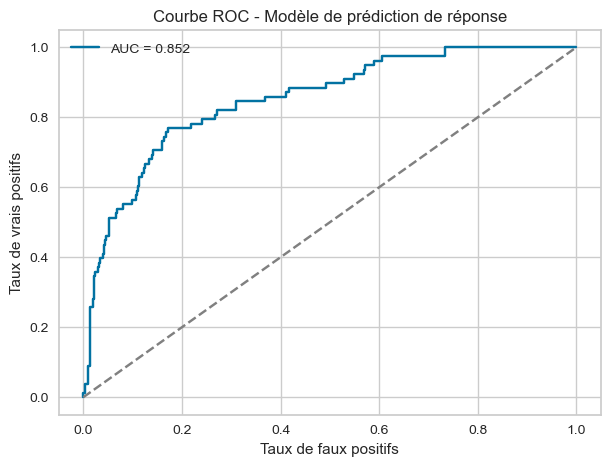

In [180]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], '--', color='grey')
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - Modèle de prédiction de réponse")
plt.legend()
plt.show()

# La courbe ROC montre la relation entre : le taux de vrais positifs (clients correctement identifiés comme répondants) et le taux de faux positifs (clients identifiés à tort comme répondants)
# Plus la courbe s’éloigne de la diagonale, plus le modèle est discriminant.
# Dans le graph, la courbe est nettement au‑dessus de la diagonale, donc le modèle sépare très bien les répondants des non‑répondants.

Intégration du score dans le dataframe

In [181]:
df['Score_Prob_Response'] = model.predict_proba(scaler.transform(X))[:, 1]

Classement des clients par probabilité

In [182]:
df['Cible_Prioritaire'] = pd.qcut(df['Score_Prob_Response'], q=5, labels=False)

# 0 = probabilité faible
# 4 = probabilité très élevée

df[['Score_Prob_Response', 'Cible_Prioritaire']].head()

,Score_Prob_Response,Cible_Prioritaire
0,0.782061,4
1,0.032111,1
2,0.071796,2
3,0.037157,1
4,0.011147,0


Ce tableau représente la probabilité prédite par le modèle qu’un client réponde à une campagne marketing. Plus le score est élevé, plus le client est susceptible de répondre. Le score est compris entre 0 et 1.

- 0.782 → 78,2 % de probabilité de réponse : Client extrêmement réactif, à cibler en priorité.
- 0.072 → 7,2 % de probabilité de réponse : Client très peu susceptible de répondre.
- 0.037 → 3,7 % de probabilité de réponse : Client très peu susceptible de répondre.
- 0.032 → 3,2 % de probabilité de réponse : Client très peu susceptible de répondre.
- 0.011 → 1,1 % de probabilité de réponse : Client à exclure des campagnes coûteuses.


**Ligne 0 : Score = 0.782**
Cible_Prioritaire = 4  
- Client dans le top 20 % des probabilités.
- Cœur de cible pour les campagnes.

**Ligne 1 : Score = 0.032**
Cible_Prioritaire = 1  
- Probabilité faible.
- À éviter dans les campagnes coûteuses.

**Ligne 2 : Score = 0.071**
Cible_Prioritaire = 2  
- Probabilité moyenne.
- Peut être ciblé dans des campagnes peu coûteuses ou automatisées.

**Ligne 3 : Score = 0.037**
Cible_Prioritaire = 1  
- Faible probabilité.
- À exclure des campagnes premium.

**Ligne 4 : Score = 0.011**
Cible_Prioritaire = 0  
- Probabilité extrêmement faible.
- À ne pas cibler.

---